# Mask (Using universalseg via Julie's masks) Wavelet Analysis — Ultrasound Body Composition

Audrey Xiao

## Install & Imports

In [7]:
!pip install -q PyWavelets scikit-image opencv-python-headless seaborn scikit-learn tqdm albumentations shap

In [8]:
import os, re, io, zipfile, warnings, random
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, LogNorm
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from scipy import ndimage
from scipy.stats import skew, kurtosis, mannwhitneyu, ttest_ind
import pywt
from skimage.filters import gabor_kernel
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold, LeaveOneGroupOut
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import cv2
from PIL import Image as PILImage
import albumentations as A
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0D0D0F', 'axes.facecolor': '#12121A',
    'axes.edgecolor': '#444', 'axes.labelcolor': 'white',
    'xtick.color': 'white', 'ytick.color': 'white',
    'text.color': 'white', 'grid.color': '#2a2a2a',
    'legend.facecolor': '#1a1a2a', 'legend.labelcolor': 'white',
})

C = dict(high_fat='#E74C3C', low_fat='#2E86C1',
         ABD='#A855F7', BICEP='#22C55E', QUAD='#F59E0B',
         mask='#FF6B6B', no_mask='#74B9FF', neutral='#636E72')

np.random.seed(30) # for reproducibility
random.seed(30)
print('Imports OK  |  PyWavelets', pywt.__version__)

Imports OK  |  PyWavelets 1.8.0


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Configuration

In [16]:
# Paths
ROOT_DIR    = "/content/gdrive/MyDrive/Body Composition 2026/combined_cropped_images"
MASTER      = "/content/drive/MyDrive/Body Composition 2026/manifests/master_patients_probe.csv"
OVERLAY_ZIP = "/content/drive/MyDrive/Body Composition 2026/MedSAM/masks/overlays"

IMG_EXTS = (".png", ".jpg", ".jpeg")
SEED     = 30
IMG_SIZE = (128, 128)   # match overlay resolution exactly

# Wavelet config - just using haar
HAAR_WAV    = 'haar'
DB4_WAV     = 'db4'
DWT_LEVEL   = 3          # 3 levels safe at 128×128
GABOR_FREQS  = [0.05, 0.10, 0.20, 0.35]
GABOR_THETAS = [0, np.pi/4, np.pi/2, 3*np.pi/4]

# fat mass and fat free
FAT_COL       = None
FAT_THRESHOLD = None   # None → median split

AUGMENT = 2   # make two copies?

print('Config OK  |  IMG_SIZE =', IMG_SIZE)

Config OK  |  IMG_SIZE = (128, 128)


## Loading Overlay Masks, extrctioon of both mask and images

Each overlay PNG encodes two things in one image: ultraosund intensity and tissue masks

We want to do wavelet on full image, mask only and outside mask


In [12]:

import glob

In [13]:
# overlay (gray_img, binary_mask)
def decode_overlay(arr: np.ndarray, mask_thresh: int = 8):
    """
    Input : RGB uint8 array (H, W, 3) from overlay PNG
    Output: gray uint8 (H, W), binary mask bool (H, W)
    Red-tinted pixels (R - G > mask_thresh) = tissue mask.
    Gray base = G channel (same as B outside mask).
    """
    arr = arr.astype(np.int16)
    R, G, B = arr[:,:,0], arr[:,:,1], arr[:,:,2]
    mask = (R - G) > mask_thresh          # True inside segmented tissue
    gray = np.clip(G, 0, 255).astype(np.uint8)  # G==B in grayscale regions
    return gray, mask

# Load all overlays from the directory
def load_overlays_from_dir(dir_path: str) -> list:
    """Returns list of dicts: {patient_id, region, frame_idx, gray, mask, path}"""
    records = []
    pat = re.compile(r'(.+?)_(abd|bicep|quad)_(\d+)\.png$', re.I)

    png_paths = glob.glob(os.path.join(dir_path, '**', '*.png'), recursive=True)
    print(f'Found {len(png_paths)} overlay PNGs in directory')

    for full_path in tqdm(png_paths, desc='Decoding overlays'):
        base = os.path.basename(full_path)
        m = pat.match(base)
        if not m:
            continue
        pid, region, fidx = m.group(1), m.group(2).upper(), int(m.group(3))
        arr = np.array(PILImage.open(full_path).convert('RGB'))
        gray, mask = decode_overlay(arr)
        records.append({
            'patient_id': pid,
            'region':     region,
            'frame_idx':  fidx,
            'gray':       gray,
            'mask':       mask,
            'path':       full_path,
            'mask_pct':   float(mask.mean() * 100),
        })

    df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('gray', 'mask')}
                       for r in records])
    print(f'Loaded {len(records)} overlays | PIDs: {df.patient_id.nunique()} patients')
    print('Region counts:', df.region.value_counts().to_dict())
    return records, df

OVERLAY_DIR = '/content/drive/MyDrive/Body Composition 2026/MedSAM/masks/overlays'
overlay_records, df_overlay = load_overlays_from_dir(OVERLAY_DIR)

Found 1279 overlay PNGs in directory


Decoding overlays:   0%|          | 0/1279 [00:00<?, ?it/s]

Loaded 1279 overlays | PIDs: 110 patients
Region counts: {'QUAD': 468, 'BICEP': 408, 'ABD': 403}


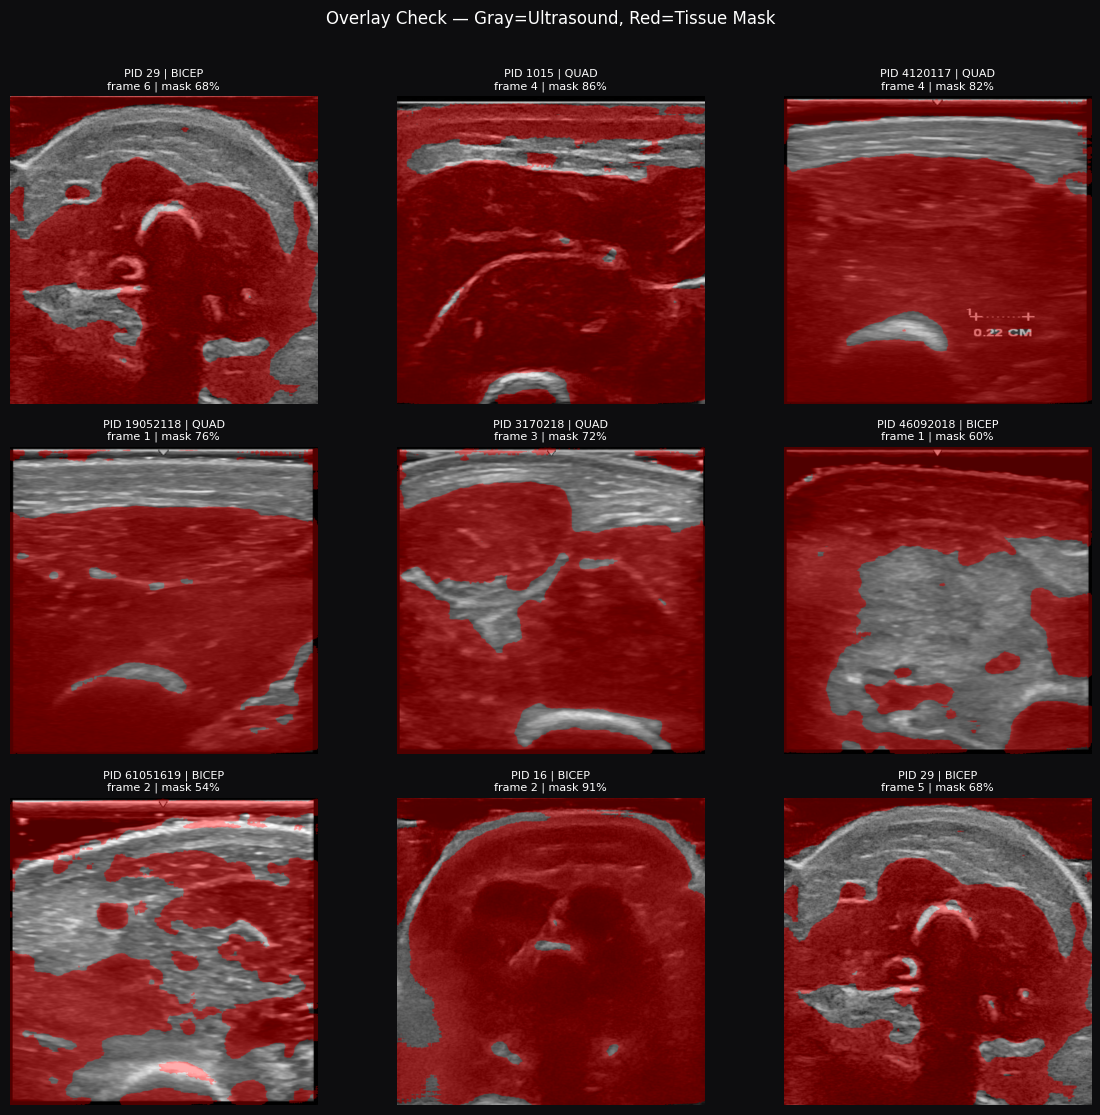

If red regions are blank → adjust mask_thresh in decode_overlay()


In [21]:
# visualise 9 overlays showing image + mask
fig, axes = plt.subplots(3, 3, figsize=(12, 11))
sample_idx = np.linspace(0, len(overlay_records)-1, 9, dtype=int)

for ax, idx in zip(axes.ravel(), sample_idx):
    rec  = overlay_records[idx]
    gray = rec['gray']
    mask = rec['mask']

    # Compose RGB: gray background + red overlay on mask
    rgb = np.stack([gray, gray, gray], axis=-1).copy()
    rgb[mask, 0] = np.clip(gray[mask].astype(int) + 80, 0, 255)  # boost red
    rgb[mask, 1] = np.clip(gray[mask].astype(int) - 30, 0, 255)  # suppress green
    rgb[mask, 2] = np.clip(gray[mask].astype(int) - 30, 0, 255)

    ax.imshow(rgb)
    ax.set_title(
    f"PID {rec['patient_id']} | {rec['region']}\nframe {rec['frame_idx']} | mask {rec['mask_pct']:.0f}%",
    fontsize=8, color='white')
    ax.axis('off')


plt.suptitle('Overlay Check — Gray=Ultrasound, Red=Tissue Mask',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig_00_overlay_sanity.png', dpi=130, bbox_inches='tight')
plt.show()
print('If red regions are blank → adjust mask_thresh in decode_overlay()')

## 3. Merge Overlays with Patient Metadata (Fat Mass)

In [17]:


df_master = pd.read_csv(MASTER)
print(f'Master CSV: {df_master.shape}')
print('Columns:', df_master.columns.tolist())
df_master.head(3)

Master CSV: (111, 13)
Columns: ['patient_id', 'site', 'fat_mass', 'fat_free_mass', 'weight', 'length', 'abd_paths', 'bicep_paths', 'quad_paths', 'n_abd', 'n_bicep', 'n_quad', 'has_all_regions']


,patient_id,site,fat_mass,fat_free_mass,weight,length,abd_paths,bicep_paths,quad_paths,n_abd,n_bicep,n_quad,has_all_regions
0,4,ethiopia,0.0055,1.9672,1.954,47.3,"[""/content/gdrive/MyDrive/Body Composition 202...","[""/content/gdrive/MyDrive/Body Composition 202...","[""/content/gdrive/MyDrive/Body Composition 202...",7,6,6,1
1,5,ethiopia,0.0801,1.4419,1.514,39.4,"[""/content/gdrive/MyDrive/Body Composition 202...","[""/content/gdrive/MyDrive/Body Composition 202...","[""/content/gdrive/MyDrive/Body Composition 202...",3,7,7,1
2,6,ethiopia,0.0354,3.3618,1.528,41.2,"[""/content/gdrive/MyDrive/Body Composition 202...","[""/content/gdrive/MyDrive/Body Composition 202...","[""/content/gdrive/MyDrive/Body Composition 202...",2,2,2,1


In [19]:
# columns for fat
if FAT_COL is None:
    fat_cands = [c for c in df_master.columns if 'fat' in c.lower()]
    print('Fat column candidates:', fat_cands)
    FAT_COL = fat_cands[0]
    print(f'→ Using FAT_COL = "{FAT_COL}"')

pid_cands = [c for c in df_master.columns
             if any(x in c.lower() for x in ['id','patient','pid','subject'])]
PID_COL = pid_cands[0] if pid_cands else df_master.columns[0]
print(f'→ Using PID_COL = "{PID_COL}"')

# Normalise types
df_master[PID_COL] = df_master[PID_COL].astype(str).str.strip()
df_overlay['patient_id'] = df_overlay['patient_id'].astype(str).str.strip()
df_master[FAT_COL] = pd.to_numeric(df_master[FAT_COL], errors='coerce')

# Fat binary label
if FAT_THRESHOLD is None:
    FAT_THRESHOLD = float(df_master[FAT_COL].dropna().median())
print(f'Fat threshold (median): {FAT_THRESHOLD:.2f}')
df_master['fat_label'] = np.where(df_master[FAT_COL] > FAT_THRESHOLD,
                                   'high_fat', 'low_fat')
print(df_master['fat_label'].value_counts())

# Merge
df_meta = df_overlay.merge(
    df_master[[PID_COL, FAT_COL, 'fat_label']],
    left_on='patient_id', right_on=PID_COL, how='left')

# Sync meta back to overlay_records
pid_to_meta = df_meta.set_index(df_meta.index)[['fat_label', FAT_COL]].to_dict('index')
for i, rec in enumerate(overlay_records):
    rec['fat_label'] = df_meta.iloc[i].get('fat_label') if i < len(df_meta) else None
    rec[FAT_COL]     = df_meta.iloc[i].get(FAT_COL)    if i < len(df_meta) else None

labelled = [r for r in overlay_records if r.get('fat_label') is not None]
print(f'Labelled records: {len(labelled)} / {len(overlay_records)}')

Fat column candidates: ['fat_mass', 'fat_free_mass']
→ Using FAT_COL = "fat_mass"
→ Using PID_COL = "patient_id"
Fat threshold (median): 0.22
fat_label
low_fat     56
high_fat    55
Name: count, dtype: int64
Labelled records: 1279 / 1279


## Data Augmentation

Augmentation is applied identically to both the ultrasound image and the binary mask,
preserving their spatial correspondence.

In [20]:
aug_tfm = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.12, contrast_limit=0.12, p=0.6),
    A.GaussNoise(var_limit=(3.0, 15.0), p=0.4),   # simulated speckle
    A.ElasticTransform(alpha=15, sigma=3, p=0.3),  # tissue deformation
    A.CLAHE(clip_limit=2.0, p=0.3),
], additional_targets={'mask_img': 'image'})

def augment_pair(gray: np.ndarray, mask: np.ndarray, n: int) -> list:
    g3 = np.stack([gray]*3, axis=-1)
    m3 = np.stack([mask.astype(np.uint8)*255]*3, axis=-1)
    pairs = []
    for _ in range(n):
        out = aug_tfm(image=g3, mask_img=m3)
        ag  = out['image'][:,:,0].astype(np.uint8)
        am  = out['mask_img'][:,:,0] > 127
        pairs.append((ag, am))
    return pairs

# Build augmented record list
all_records = list(overlay_records)   # originals
if AUGMENT > 0:
    aug_batch = []
    for rec in tqdm(labelled, desc='Augmenting'):
        for ag, am in augment_pair(rec['gray'], rec['mask'], AUGMENT):
            r = {k: v for k, v in rec.items() if k not in ('gray','mask')}
            r['gray'] = ag; r['mask'] = am
            r['augmented'] = True
            aug_batch.append(r)
    all_records += aug_batch

for r in overlay_records:
    r.setdefault('augmented', False)

print(f'Total records: {len(all_records)} '
      f'(orig={len(overlay_records)}, aug={len(aug_batch) if AUGMENT else 0})')

Augmenting:   0%|          | 0/1279 [00:00<?, ?it/s]

Total records: 3837 (orig=1279, aug=2558)


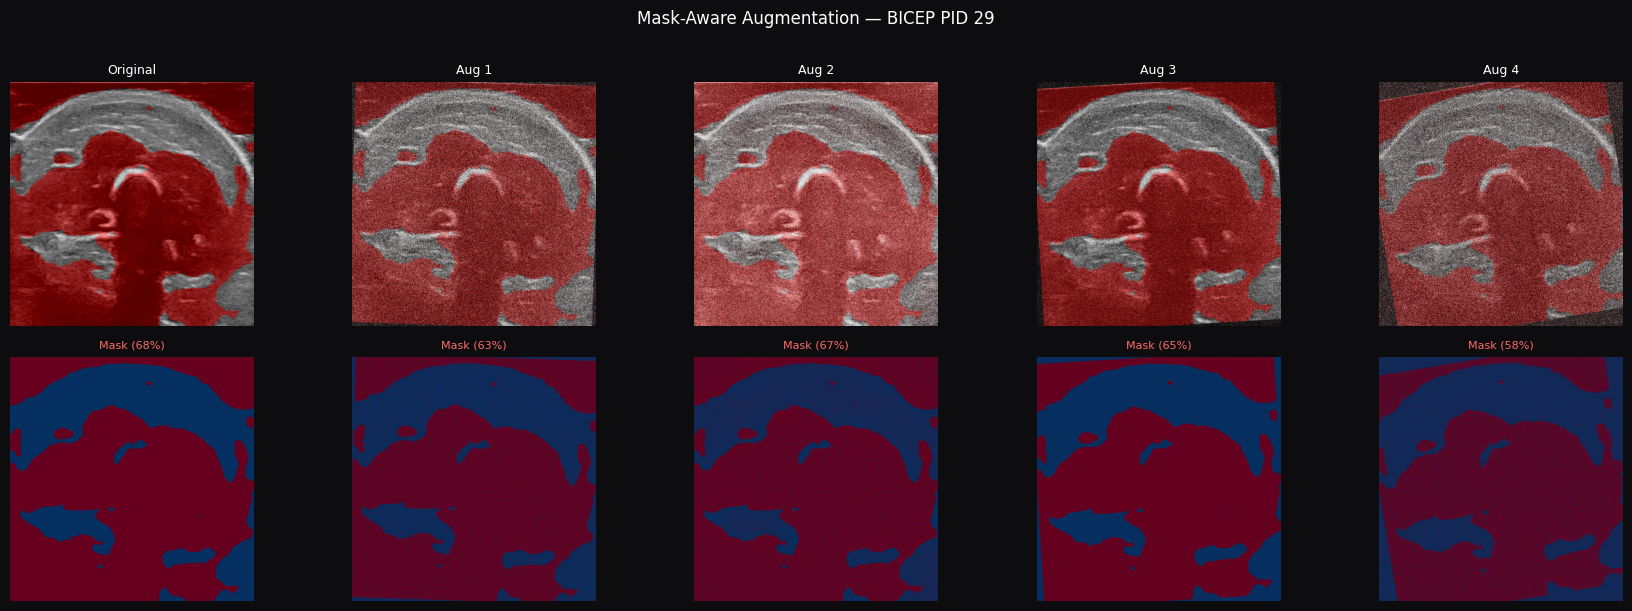

In [22]:
# Visualise augmentation with mask alignment
orig = labelled[0]
pairs = augment_pair(orig['gray'], orig['mask'], 4)
n_show = 5
fig, axes = plt.subplots(2, n_show, figsize=(3.5*n_show, 6))

for ci, (gray, mask) in enumerate([(orig['gray'], orig['mask'])] + pairs):
    rgb = np.stack([gray]*3, axis=-1).copy().astype(np.float32)
    rgb[mask, 0] = np.clip(rgb[mask, 0] + 80, 0, 255)
    rgb[mask, 1] = np.clip(rgb[mask, 1] - 30, 0, 255)
    rgb[mask, 2] = np.clip(rgb[mask, 2] - 30, 0, 255)
    axes[0, ci].imshow(rgb.astype(np.uint8))
    axes[0, ci].set_title('Original' if ci==0 else f'Aug {ci}',
                            color='white', fontsize=9)
    axes[0, ci].axis('off')
    axes[1, ci].imshow(mask, cmap='RdBu_r')
    axes[1, ci].set_title(f'Mask ({mask.mean()*100:.0f}%)',
                            color=C['mask'], fontsize=8)
    axes[1, ci].axis('off')

axes[0,0].set_ylabel('Overlay', color='white')
axes[1,0].set_ylabel('Binary Mask', color='white')
plt.suptitle(f'Mask-Aware Augmentation — {orig["region"]} PID {orig["patient_id"]}',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig_01_augmentation.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. Wavelet Decomposition on Ultrasound Images

### What each subband tells us biologically- interpretation of the layers of wavelet

| Approximation | Low-frequency structure | Overall tissue brightness, global echogenicity |
| cH (Horizontal) | Horizontal edges | Layer boundaries (fat/muscle interfaces), fascial planes |
| V (Vertical)   | Vertical edges  | Needle-track artifacts, vertical tissue striations |
| cD (Diagonal)   | Diagonal texture | Speckle patterns, fibre orientation |
| High levels (L3) | Coarse structure | Global anatomy shape |
| Low levels (L1) | Fine texture     | Speckle, fibril-level detail |

Haar wavelet: sharp, box-like filter — excellent for detecting abrupt transitions (fat/muscle boundaries).  
Db4 wavelet: smoother filter — better at capturing gradual textural changes (connective tissue).

In [24]:
def dwt2(img, wavelet, level):
    return pywt.wavedec2(img.astype(np.float64)/255.0, wavelet=wavelet, level=level)

def plot_dwt_explained(gray, mask, wavelet, level, title='', save=None):
    coeffs = dwt2(gray, wavelet, level)

    # Build panel: col 0 = original+mask, col 1 = approx, cols 2..N = detail energy maps
    n_cols = level + 2
    fig    = plt.figure(figsize=(4.2*n_cols, 12))
    gs     = gridspec.GridSpec(1, n_cols, figure=fig, wspace=0.05)

    # Col 0: original image with mask overlay
    ax0 = fig.add_subplot(gs[0, 0])
    rgb = np.stack([gray]*3, axis=-1).copy().astype(float)
    rgb[mask, 0] = np.clip(rgb[mask, 0]+80, 0, 255)
    rgb[mask, 1] = np.clip(rgb[mask, 1]-30, 0, 255)
    rgb[mask, 2] = np.clip(rgb[mask, 2]-30, 0, 255)
    ax0.imshow(rgb.astype(np.uint8))
    ax0.set_title('Input\n(red=mask)', color='white', fontsize=10)
    ax0.axis('off')

    # Col 1: approximation
    ax1 = fig.add_subplot(gs[0, 1])
    arr = np.abs(coeffs[0])
    ax1.imshow(arr, cmap='bone', vmin=arr.min(), vmax=arr.max())
    ax1.set_title(f'Approximation (L{level})\nLow-freq structure',
                  color='white', fontsize=9)
    ax1.axis('off')

    bio = {
        'H': 'Horiz edges\n(tissue layer boundaries)',
        'V': 'Vert edges\n(striations / artifacts)',
        'D': 'Diagonal texture\n(speckle / fibre orient.)',
    }
    cmaps = ['RdBu_r', 'PRGn', 'PiYG']

    for col in range(level):
        detail_idx = level - col   # coarsest first
        cH, cV, cD = coeffs[detail_idx]
        inner = gridspec.GridSpecFromSubplotSpec(
            3, 1, subplot_spec=gs[0, col+2], hspace=0.1)
        for si, (c, sb, cm) in enumerate(zip([cH,cV,cD], ['H','V','D'], cmaps)):
            ax = fig.add_subplot(inner[si, 0])
            vmax = float(np.percentile(np.abs(c), 99)) or 1e-6
            ax.imshow(c, cmap=cm, vmin=-vmax, vmax=vmax)
            ax.set_title(
                f'L{detail_idx} c{sb}\n{bio[sb]}',
                color='#CCCCCC', fontsize=7)
            ax.axis('off')

    plt.suptitle(f'{wavelet.upper()} DWT — {title}',
                 color='white', fontsize=13, y=1.01)
    if save: plt.savefig(save, dpi=130, bbox_inches='tight')
    plt.show(); plt.close()

# Run for one representative image per region
for region in ['ABD','BICEP','QUAD']:
    recs = [r for r in labelled if r['region']==region]
    if not recs: continue
    r = recs[0]
    plot_dwt_explained(r['gray'], r['mask'], HAAR_WAV, DWT_LEVEL,
                       title=f'{region} | {r["fat_label"]} | PID {r["patient_id"]}',
                       save=f'fig_02_haar_decomp_{region}.png')

Output hidden; open in https://colab.research.google.com to view.

## Masked vs. Full-Image Wavelet Analysis

Does restricting wavelet analysis to the segmented tissue region (mask) provide more discriminative signal than the full image?

This matters for domain generalization — if mask-based features are more consistent across probe positions and body habitus variations, they're more likely to generalize to new patients.

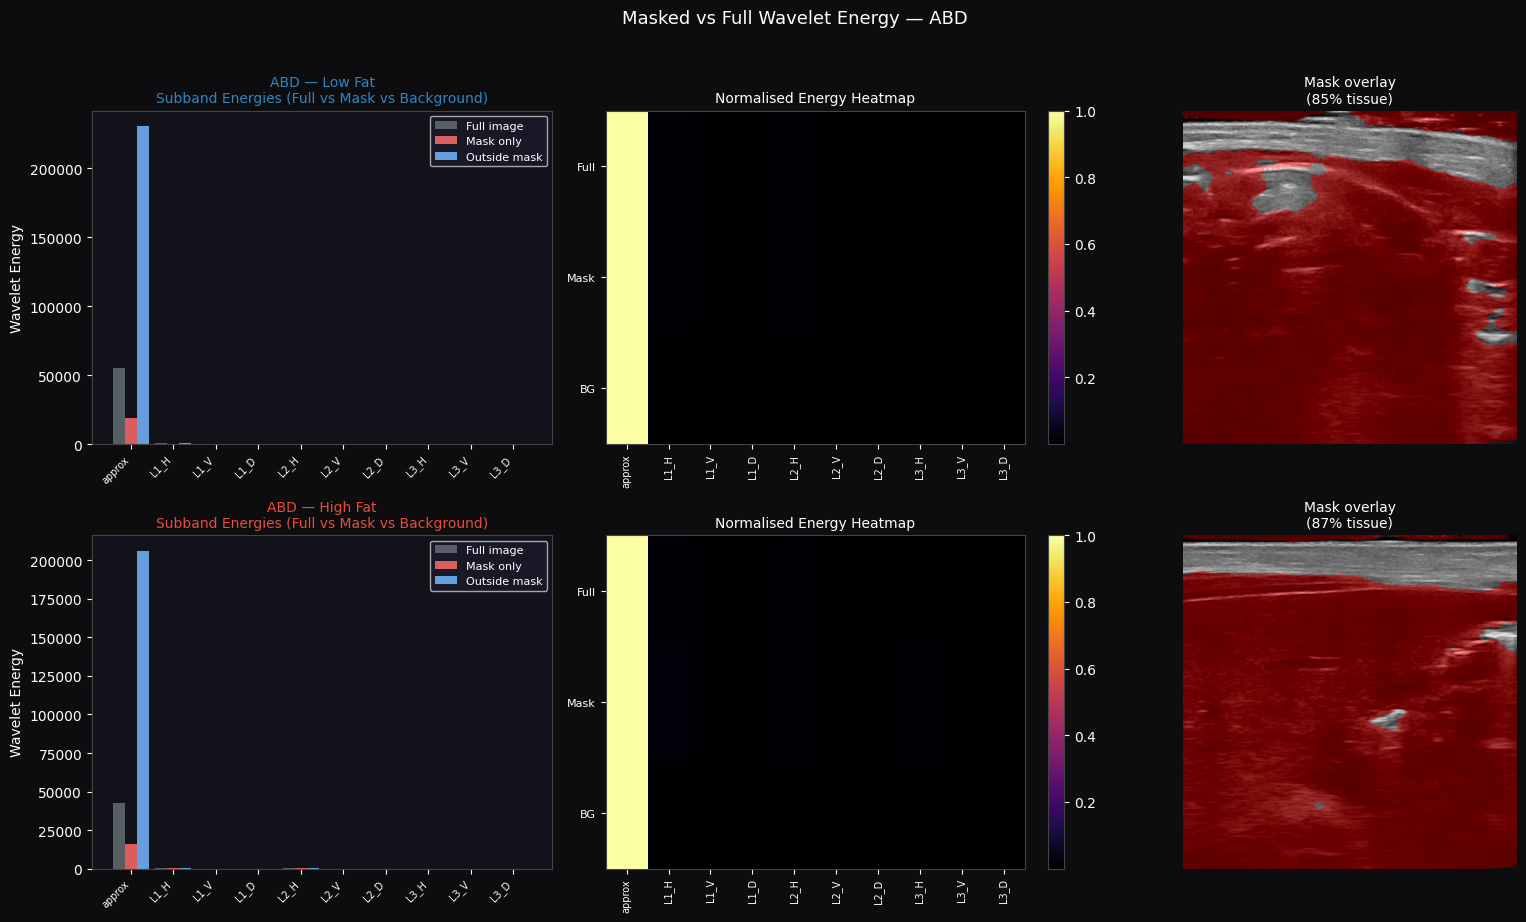

In [25]:
def dwt_energy_profile(img_f, wavelet, level):
    """Returns dict of {subband: energy} for all subbands across all levels."""
    coeffs = pywt.wavedec2(img_f, wavelet=wavelet, level=level)
    energies = {'approx': float(np.sum(coeffs[0]**2))}
    for lv in range(1, level+1):
        for sb, c in zip(['H','V','D'], coeffs[lv]):
            energies[f'L{lv}_{sb}'] = float(np.sum(c**2))
    return energies

def masked_wavelet_energy(gray, mask, wavelet, level):
    """
    Compute wavelet energies three ways:
      1. full image  2. mask-only (tissue)  3. outside mask (background)
    For mask-only: set background pixels to mean before DWT to avoid
    edge artifacts from hard boundary.
    """
    img_f = gray.astype(np.float64) / 255.0
    mu    = img_f[mask].mean() if mask.any() else img_f.mean()

    # Full image
    e_full = dwt_energy_profile(img_f, wavelet, level)

    # Masked image: replace outside with tissue mean
    img_masked = img_f.copy(); img_masked[~mask] = mu
    e_mask = dwt_energy_profile(img_masked, wavelet, level)

    # Outside image: replace inside with background mean
    mu_bg = img_f[~mask].mean() if (~mask).any() else img_f.mean()
    img_bg = img_f.copy(); img_bg[mask] = mu_bg
    e_bg   = dwt_energy_profile(img_bg, wavelet, level)

    return e_full, e_mask, e_bg

# Demonstrate on one high-fat vs one low-fat (same region)
for region in ['ABD','BICEP','QUAD']:
    hi = [r for r in labelled if r['region']==region and r['fat_label']=='high_fat']
    lo = [r for r in labelled if r['region']==region and r['fat_label']=='low_fat']
    if not hi or not lo:
        continue

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    for ri, (rec, lbl) in enumerate([(lo[0],'Low Fat'),(hi[0],'High Fat')]):
        ef, em, eb = masked_wavelet_energy(rec['gray'], rec['mask'],
                                            HAAR_WAV, DWT_LEVEL)
        keys = list(ef.keys())
        x    = np.arange(len(keys))
        w    = 0.28
        ax   = axes[ri, 0]
        ax.bar(x-w, [ef[k] for k in keys], w, label='Full image',  color='#636E72', alpha=0.85)
        ax.bar(x,   [em[k] for k in keys], w, label='Mask only',   color=C['mask'], alpha=0.85)
        ax.bar(x+w, [eb[k] for k in keys], w, label='Outside mask',color=C['no_mask'], alpha=0.85)
        ax.set_xticks(x); ax.set_xticklabels(keys, rotation=45, ha='right', fontsize=7)
        ax.set_title(f'{region} — {lbl}\nSubband Energies (Full vs Mask vs Background)',
                     color=C['high_fat' if lbl=='High Fat' else 'low_fat'], fontsize=10)
        ax.set_ylabel('Wavelet Energy'); ax.legend(fontsize=8)

        # Energy map: tissue region
        arr_full = np.array([(ef[k], em[k], eb[k]) for k in keys])
        arr_full /= (arr_full.max(axis=0, keepdims=True) + 1e-9)
        im = axes[ri, 1].imshow(arr_full.T, cmap='inferno', aspect='auto')
        axes[ri, 1].set_xticks(range(len(keys)))
        axes[ri, 1].set_xticklabels(keys, rotation=90, fontsize=7)
        axes[ri, 1].set_yticks([0,1,2])
        axes[ri, 1].set_yticklabels(['Full','Mask','BG'], fontsize=8)
        axes[ri, 1].set_title('Normalised Energy Heatmap', fontsize=10)
        plt.colorbar(im, ax=axes[ri,1], fraction=0.04)

        # Show the mask
        rgb = np.stack([rec['gray']]*3, axis=-1).copy().astype(float)
        rgb[rec['mask'], 0] = np.clip(rgb[rec['mask'], 0]+80, 0, 255)
        rgb[rec['mask'], 1] = np.clip(rgb[rec['mask'], 1]-30, 0, 255)
        rgb[rec['mask'], 2] = np.clip(rgb[rec['mask'], 2]-30, 0, 255)
        axes[ri, 2].imshow(rgb.astype(np.uint8))
        axes[ri, 2].set_title(f'Mask overlay\n({rec["mask_pct"]:.0f}% tissue)',
                               fontsize=10)
        axes[ri, 2].axis('off')

    plt.suptitle(f'Masked vs Full Wavelet Energy — {region}',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(f'fig_03_masked_energy_{region}.png', dpi=130, bbox_inches='tight')
    plt.show(); plt.close()
    break  # remove to run all 3 regions

## Wavelet Energy Heatmaps: High-Fat vs Low-Fat Tissue


Fat infiltration in muscle tissue means brighter pixels and changes the texture spectrum.
Specifically:
- Higher energy in coarse detail bands (L3) fat globules are large features
- Lower energy in fine bands (L1): muscle fibre microstructure is disrupted
- Reduced horizontal edge energy (cH): fewer sharp layer boundaries in fatty muscle

In [26]:
def subband_energy_map(gray, mask, wavelet, level, use_mask=True):
    """Energy map at each pixel, averaged over subbands at each level."""
    img_f = gray.astype(np.float64)/255.0
    if use_mask:
        mu = img_f[mask].mean() if mask.any() else 0.5
        img_f[~mask] = mu
    coeffs = pywt.wavedec2(img_f, wavelet=wavelet, level=level)
    # Upsample each detail level back to original size for comparison
    maps = []
    for lv in range(1, level+1):
        cH, cV, cD = coeffs[lv]
        energy = np.sqrt(cH**2 + cV**2 + cD**2)
        energy_up = cv2.resize(energy.astype(np.float32), gray.shape[::-1],
                                interpolation=cv2.INTER_LINEAR)
        maps.append(energy_up)
    return maps   # list of (H,W) energy maps, index 0 = finest detail

# ─── Mean energy maps across high-fat vs low-fat groups ──────────────────────
for region in ['ABD','BICEP','QUAD']:
    hi_recs = [r for r in labelled if r['region']==region and r['fat_label']=='high_fat']
    lo_recs = [r for r in labelled if r['region']==region and r['fat_label']=='low_fat']
    if not hi_recs or not lo_recs:
        print(f'⚠ {region}: missing group')
        continue
    print(f'{region}: n_hi={len(hi_recs)} n_lo={len(lo_recs)}')

    # Average energy maps across subjects
    def mean_maps(recs, n_lvl):
        stacks = [[] for _ in range(n_lvl)]
        for rec in recs:
            maps = subband_energy_map(rec['gray'], rec['mask'], HAAR_WAV, DWT_LEVEL)
            for li in range(n_lvl):
                stacks[li].append(maps[li])
        return [np.mean(s, axis=0) for s in stacks]

    hi_maps = mean_maps(hi_recs, DWT_LEVEL)
    lo_maps = mean_maps(lo_recs, DWT_LEVEL)

    fig, axes = plt.subplots(3, DWT_LEVEL+1, figsize=(4.5*(DWT_LEVEL+1), 11))

    # Row 0: sample images
    axes[0,0].imshow(lo_recs[0]['gray'], cmap='bone', vmin=0, vmax=255)
    axes[0,0].set_title(f'Low Fat — example\n(n={len(lo_recs)})',
                         color=C['low_fat'], fontsize=10); axes[0,0].axis('off')
    axes[0,1].imshow(hi_recs[0]['gray'], cmap='bone', vmin=0, vmax=255)
    axes[0,1].set_title(f'High Fat — example\n(n={len(hi_recs)})',
                         color=C['high_fat'], fontsize=10); axes[0,1].axis('off')
    for ci in range(2, DWT_LEVEL+1):
        axes[0,ci].set_visible(False)

    # Rows 1-2: energy maps
    for ri, (maps, lbl, clr) in enumerate(
            [(lo_maps,'Low Fat',C['low_fat']),
             (hi_maps,'High Fat',C['high_fat'])], start=1):
        for li in range(DWT_LEVEL):
            vmax = max(np.percentile(maps[li], 99), 1e-6)
            im = axes[ri, li].imshow(maps[li], cmap='inferno',
                                      vmin=0, vmax=vmax)
            axes[ri, li].set_title(
                f'{lbl}\nL{li+1} energy ({"fine" if li==0 else "coarse"} detail)',
                color=clr, fontsize=9)
            axes[ri, li].axis('off')
            plt.colorbar(im, ax=axes[ri,li], fraction=0.04)
        axes[ri, DWT_LEVEL].set_visible(False)

    # Difference map
    for li in range(DWT_LEVEL):
        diff = hi_maps[li] - lo_maps[li]
        vmax = max(np.abs(diff).max(), 1e-6)
        ax_d = axes[1, DWT_LEVEL] if li == 0 else None
    # Create a 4th column for difference
    fig2, axd = plt.subplots(1, DWT_LEVEL, figsize=(4*DWT_LEVEL, 3.5))
    for li in range(DWT_LEVEL):
        diff = hi_maps[li] - lo_maps[li]
        vmax = max(np.abs(diff).max(), 1e-6)
        im2  = axd[li].imshow(diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        axd[li].set_title(f'Hi−Lo Difference\nL{li+1}', fontsize=9)
        axd[li].axis('off')
        plt.colorbar(im2, ax=axd[li], fraction=0.04)
        # Annotate interpretation
        net = diff.mean()
        interp = 'Hi>Lo (more energy)' if net > 0 else 'Lo>Hi (less energy)'
        axd[li].set_xlabel(interp, color='white', fontsize=7)
    fig2.patch.set_facecolor('#0D0D0F')
    plt.suptitle(f'Energy Difference Maps (High−Low Fat) — {region}',
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(f'fig_04_energy_diff_{region}.png', dpi=130, bbox_inches='tight')
    plt.show(); plt.close('all')

Output hidden; open in https://colab.research.google.com to view.

## Gabor Wavelet


Gabor filters are band-pass filters tuned to specific spatial frequencies.


Gabor bank: 16 filters


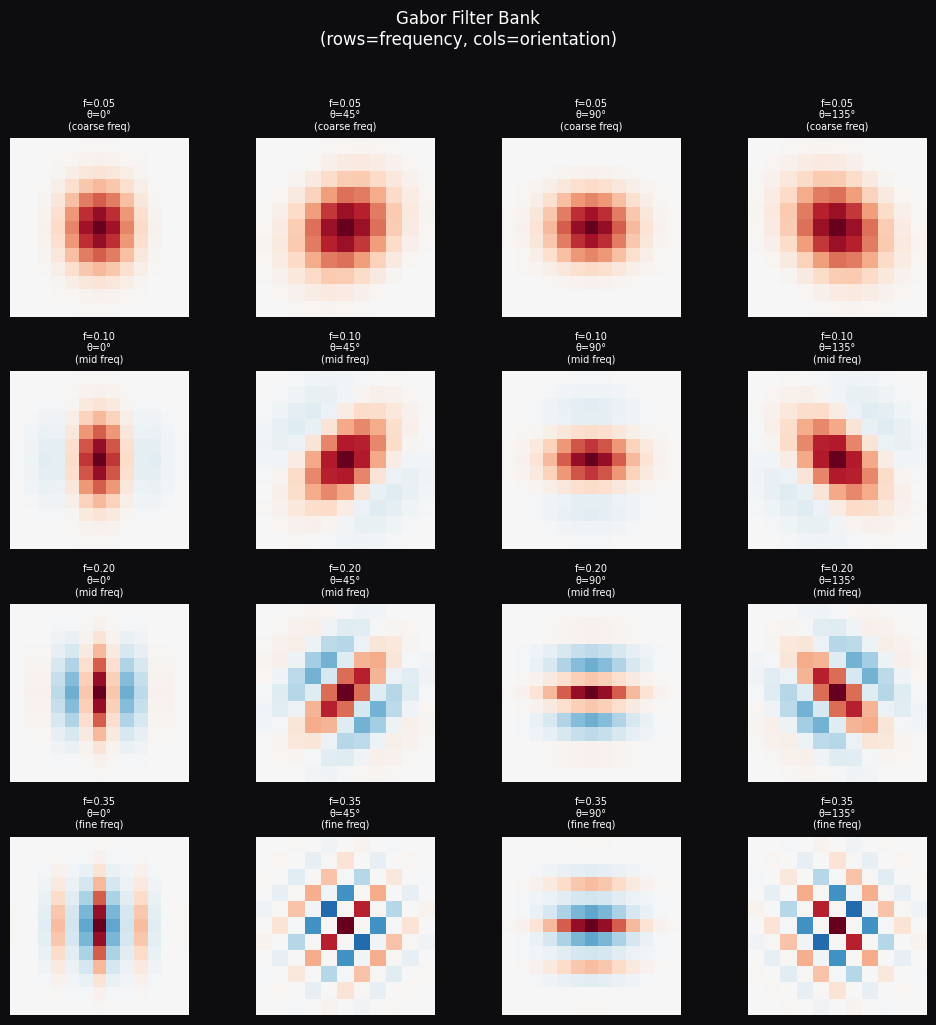

In [27]:
nf, nt = len(GABOR_FREQS), len(GABOR_THETAS)
gabor_bank = []
for f in GABOR_FREQS:
    for t in GABOR_THETAS:
        k = np.real(gabor_kernel(frequency=f, theta=t, sigma_x=2.0, sigma_y=2.0))
        gabor_bank.append({'kernel': k, 'freq': f, 'theta': t})
print(f'Gabor bank: {len(gabor_bank)} filters')

# Visualise the bank
fig, axes = plt.subplots(nf, nt, figsize=(nt*2.5, nf*2.5))
for i, f in enumerate(GABOR_FREQS):
    for j, t in enumerate(GABOR_THETAS):
        k  = gabor_bank[i*nt+j]['kernel']
        vm = max(float(np.abs(k).max()), 1e-9)
        axes[i,j].imshow(k, cmap='RdBu_r', vmin=-vm, vmax=vm)
        axes[i,j].set_title(
            f'f={f:.2f}\nθ={np.degrees(t):.0f}°\n'
            f'({"coarse" if f<0.1 else ("mid" if f<0.25 else "fine")} freq)',
            color='white', fontsize=7)
        axes[i,j].axis('off')
plt.suptitle('Gabor Filter Bank\n(rows=frequency, cols=orientation)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig_05_gabor_bank.png', dpi=130, bbox_inches='tight')
plt.show(); plt.close()

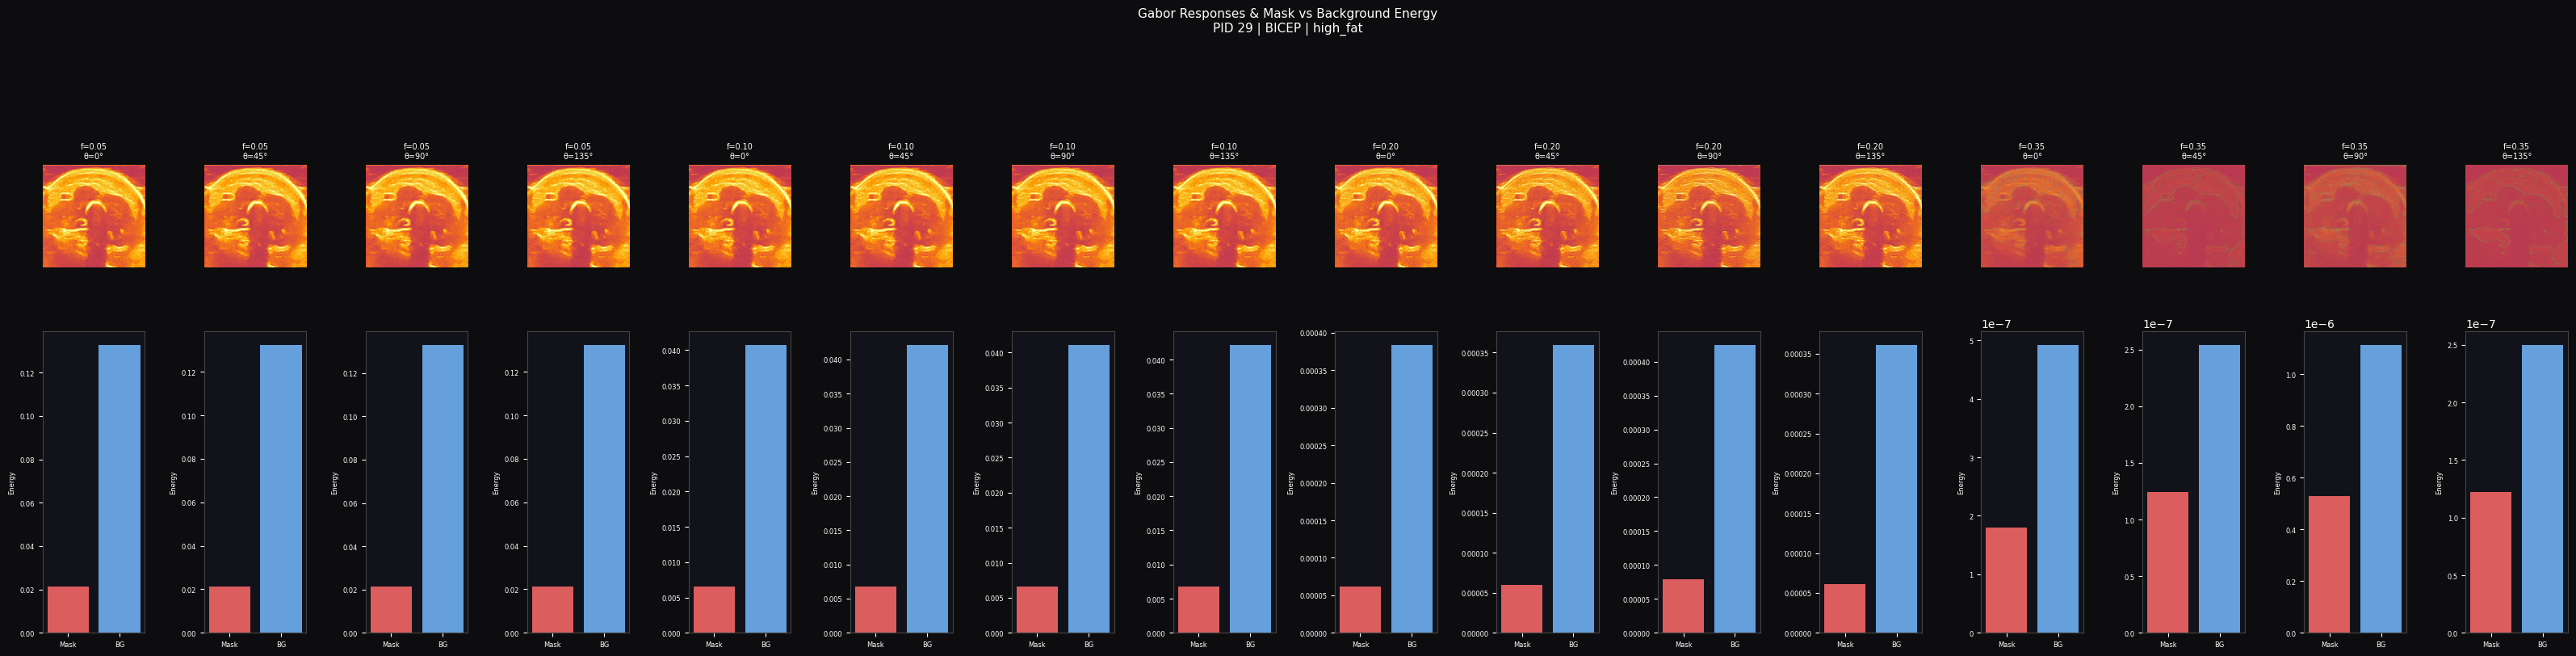

In [28]:
def apply_gabor(img, bank):
    img_f = img.astype(np.float32)/255.0
    return np.stack([ndimage.convolve(img_f, item['kernel'], mode='reflect')
                     for item in bank], axis=0)

# Gabor energy inside vs outside mask
fig, axes = plt.subplots(2, len(gabor_bank), figsize=(len(gabor_bank)*2, 8))
ref_rec = labelled[0]
resps   = apply_gabor(ref_rec['gray'], gabor_bank)
mask_r  = ref_rec['mask']

for idx, item in enumerate(gabor_bank):
    r    = resps[idx]
    vmax = max(float(np.percentile(np.abs(r), 98)), 1e-6)

    axes[0, idx].imshow(r, cmap='inferno', vmin=-vmax, vmax=vmax)
    axes[0, idx].set_title(
        f'f={item["freq"]:.2f}\nθ={np.degrees(item["theta"]):.0f}°',
        color='white', fontsize=7)
    axes[0, idx].axis('off')

    # Energy inside vs outside mask
    e_in  = float(np.mean(r[mask_r]**2))  if mask_r.any()   else 0
    e_out = float(np.mean(r[~mask_r]**2)) if (~mask_r).any() else 0
    axes[1, idx].bar(['Mask','BG'], [e_in, e_out],
                      color=[C['mask'], C['no_mask']], alpha=0.85)
    axes[1, idx].tick_params(labelsize=6)
    axes[1, idx].set_ylabel('Energy', fontsize=6)

plt.suptitle(
    f'Gabor Responses & Mask vs Background Energy\n'
    f'PID {ref_rec["patient_id"]} | {ref_rec["region"]} | {ref_rec["fat_label"]}',
    fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('fig_06_gabor_responses.png', dpi=130, bbox_inches='tight')
plt.show(); plt.close()

KeyboardInterrupt: 

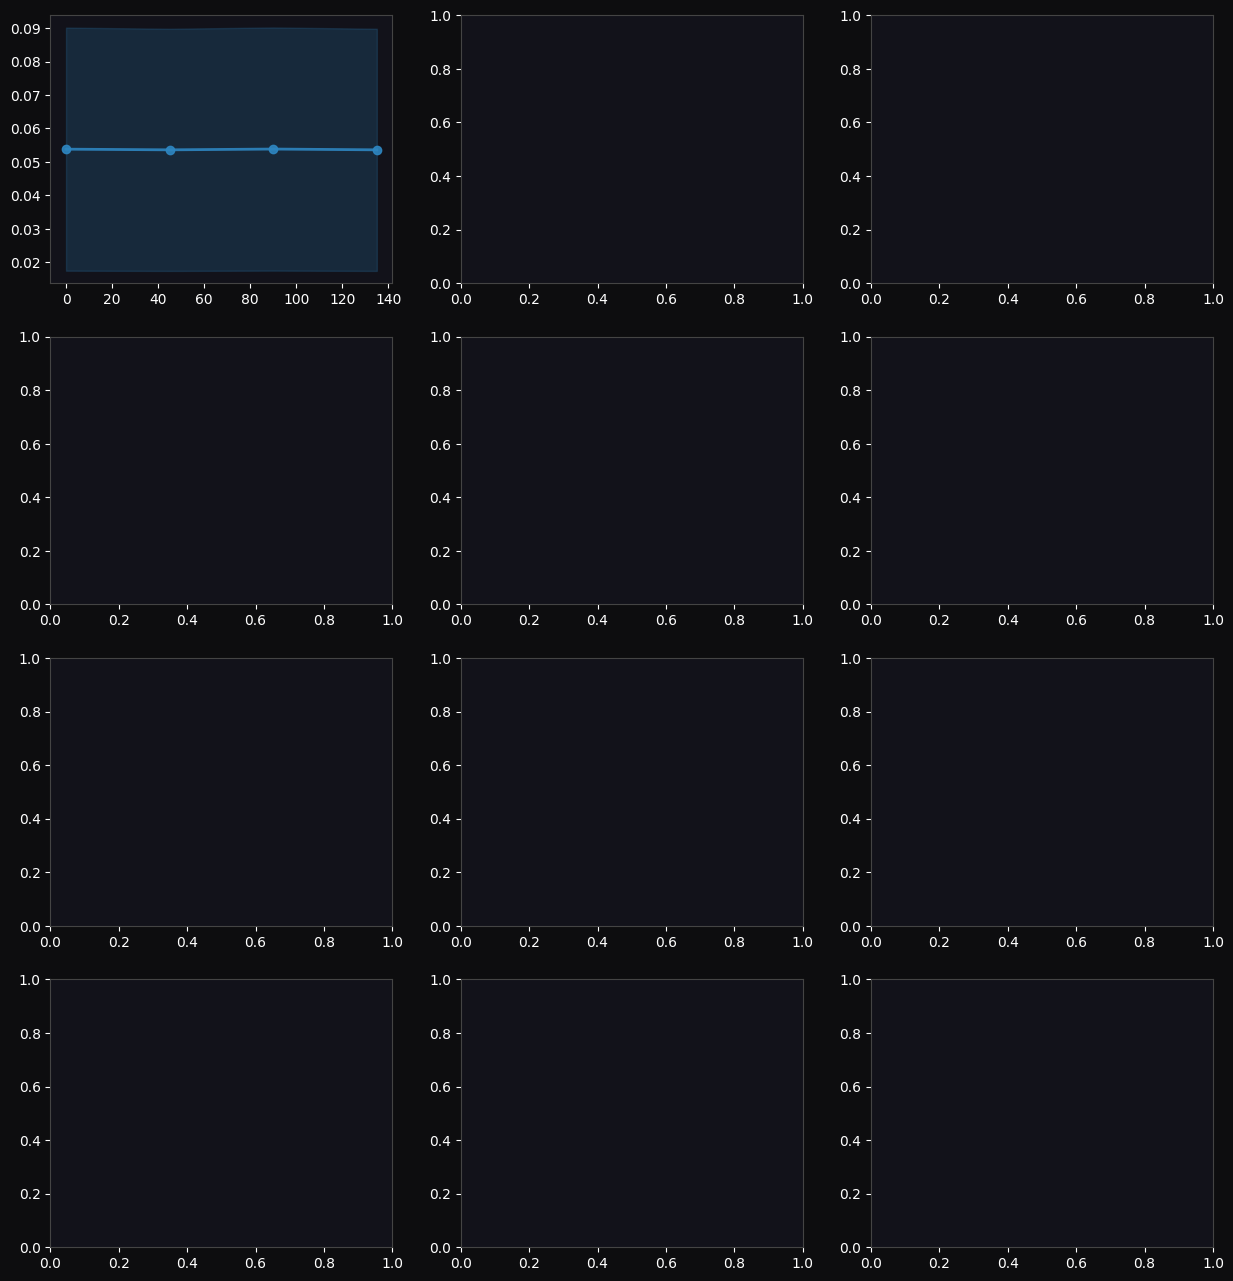

In [29]:
# Gabor energy comparison: high vs low fat per region
fig, axes = plt.subplots(len(GABOR_FREQS), 3,
                          figsize=(15, 4*len(GABOR_FREQS)))
for ri, region in enumerate(['ABD','BICEP','QUAD']):
    hi = [r for r in labelled if r['region']==region and r['fat_label']=='high_fat']
    lo = [r for r in labelled if r['region']==region and r['fat_label']=='low_fat']

    for fi, freq in enumerate(GABOR_FREQS):
        ax = axes[fi, ri]
        bank_f = [b for b in gabor_bank if b['freq']==freq]  # 4 orientations

        for recs, lbl, clr in [(lo,'Low Fat',C['low_fat']),(hi,'High Fat',C['high_fat'])]:
            if not recs: continue
            # Mean energy per orientation, inside mask
            means = []
            for rec in recs:
                resps_r = apply_gabor(rec['gray'], bank_f)
                m       = rec['mask']
                means.append([float(np.mean(resps_r[ti][m]**2)) if m.any() else 0
                               for ti in range(len(bank_f))])
            means = np.array(means)
            thetas_deg = [np.degrees(b['theta']) for b in bank_f]
            ax.plot(thetas_deg, means.mean(axis=0), 'o-', color=clr, lw=2,
                    label=lbl, alpha=0.9)
            ax.fill_between(thetas_deg,
                             means.mean(axis=0) - means.std(axis=0),
                             means.mean(axis=0) + means.std(axis=0),
                             alpha=0.2, color=clr)

        ax.set_title(f'{region} | f={freq:.2f} cyc/px\n'
                     f'({"coarse" if freq<0.1 else ("mid" if freq<0.25 else "fine")} scale)',
                     fontsize=9)
        ax.set_xlabel('Orientation (°)')
        ax.set_ylabel('Mean Gabor Energy (mask)')
        if fi==0 and ri==0: ax.legend(fontsize=8)

plt.suptitle('Gabor Energy vs Orientation — High vs Low Fat, All Regions\n'
             '(inside segmented tissue mask only)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig_07_gabor_fat_orientation.png', dpi=130, bbox_inches='tight')
plt.show(); plt.close()

## CWT Scalogram — Spatial Frequency Profile Along Tissue

The Continuous Wavelet Transform (CWT) scalogram shows how frequency content varies spatially along a single scan line through the tissue.  


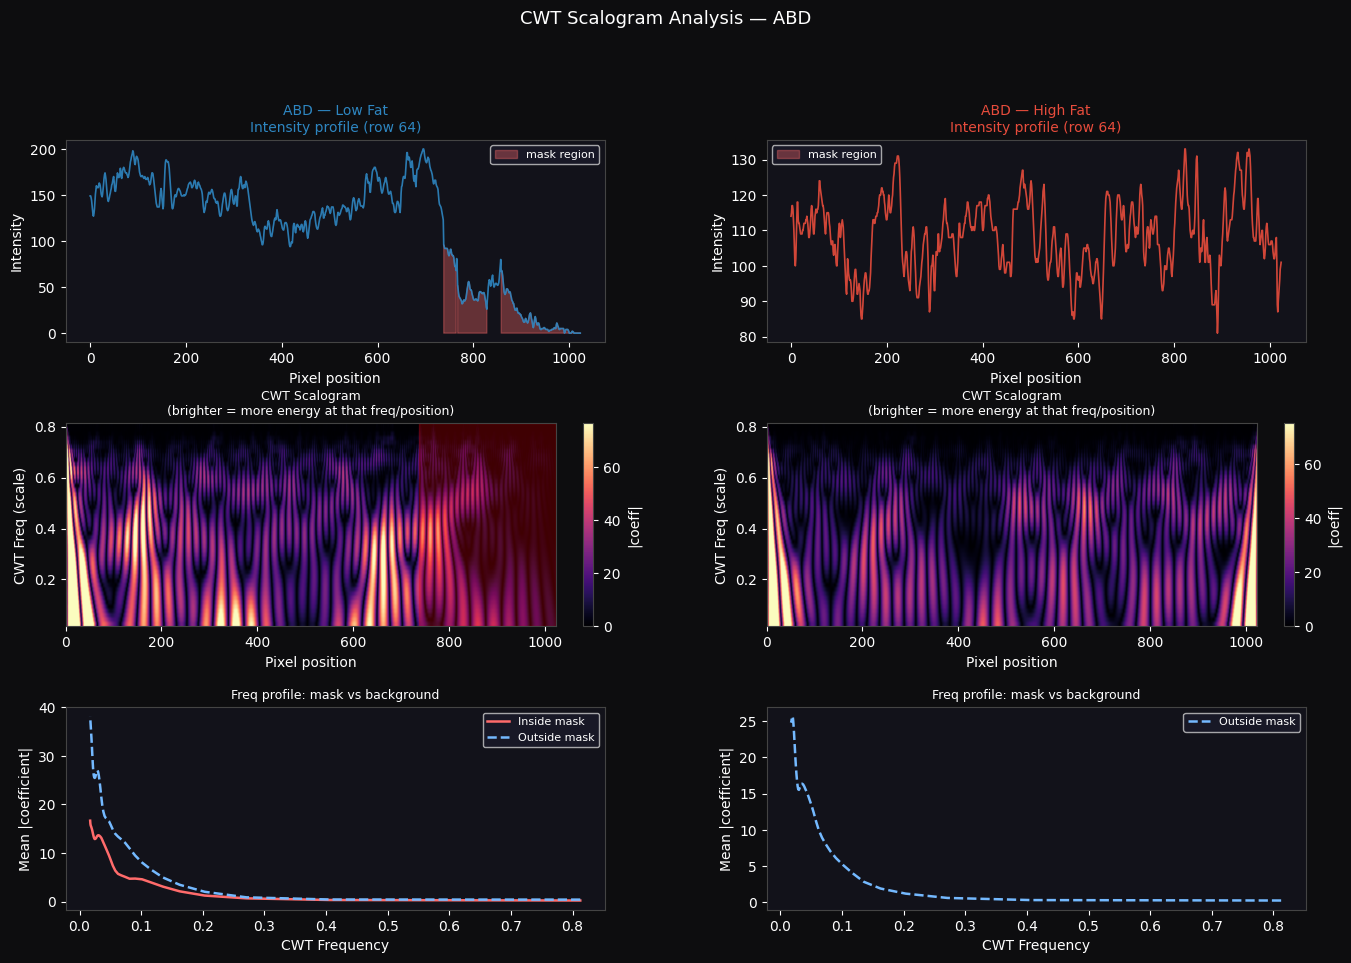

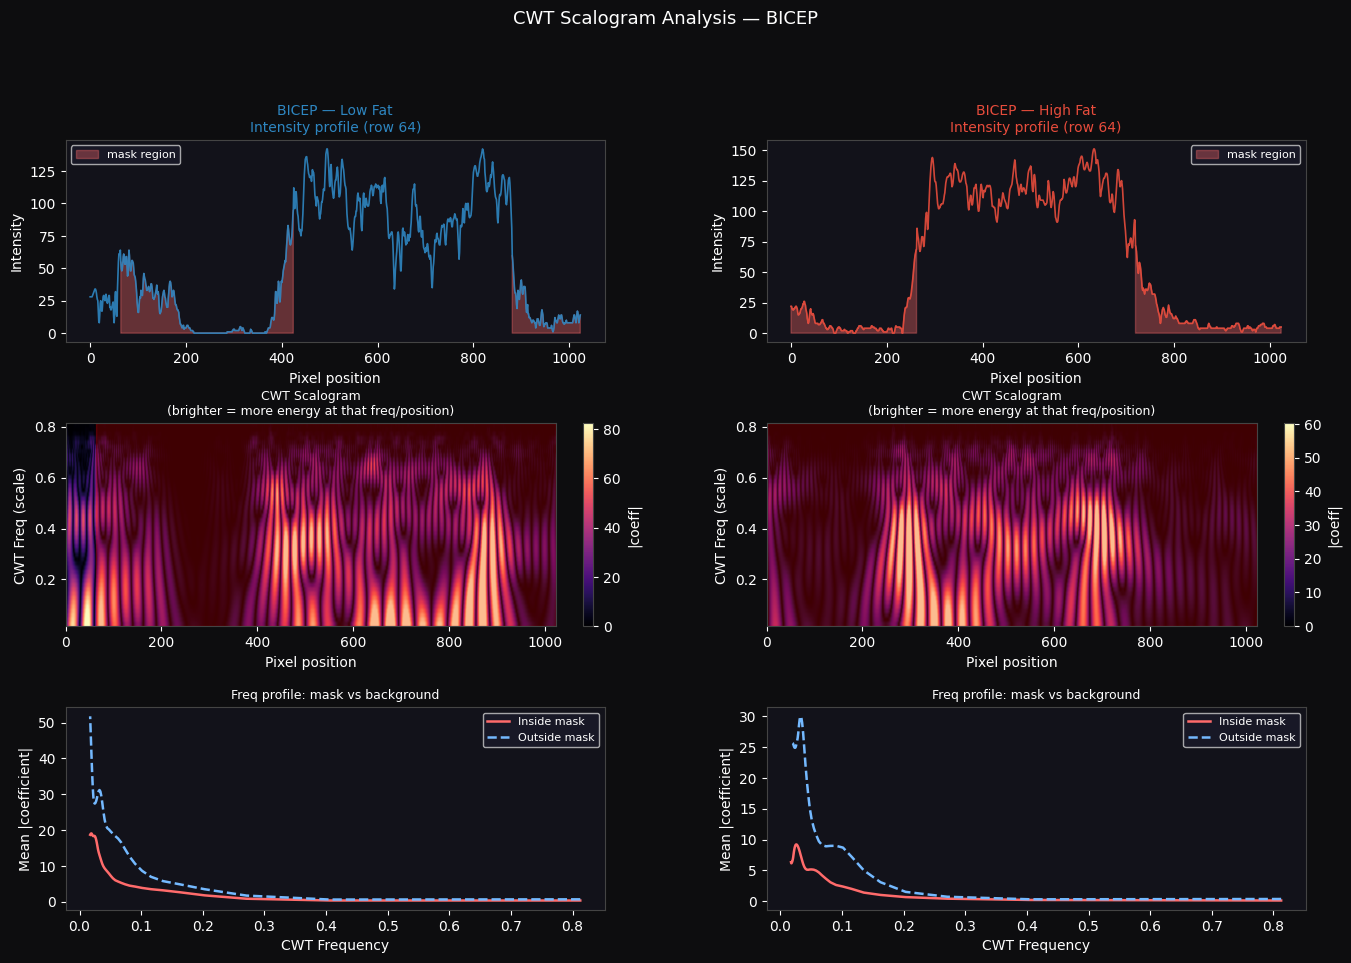

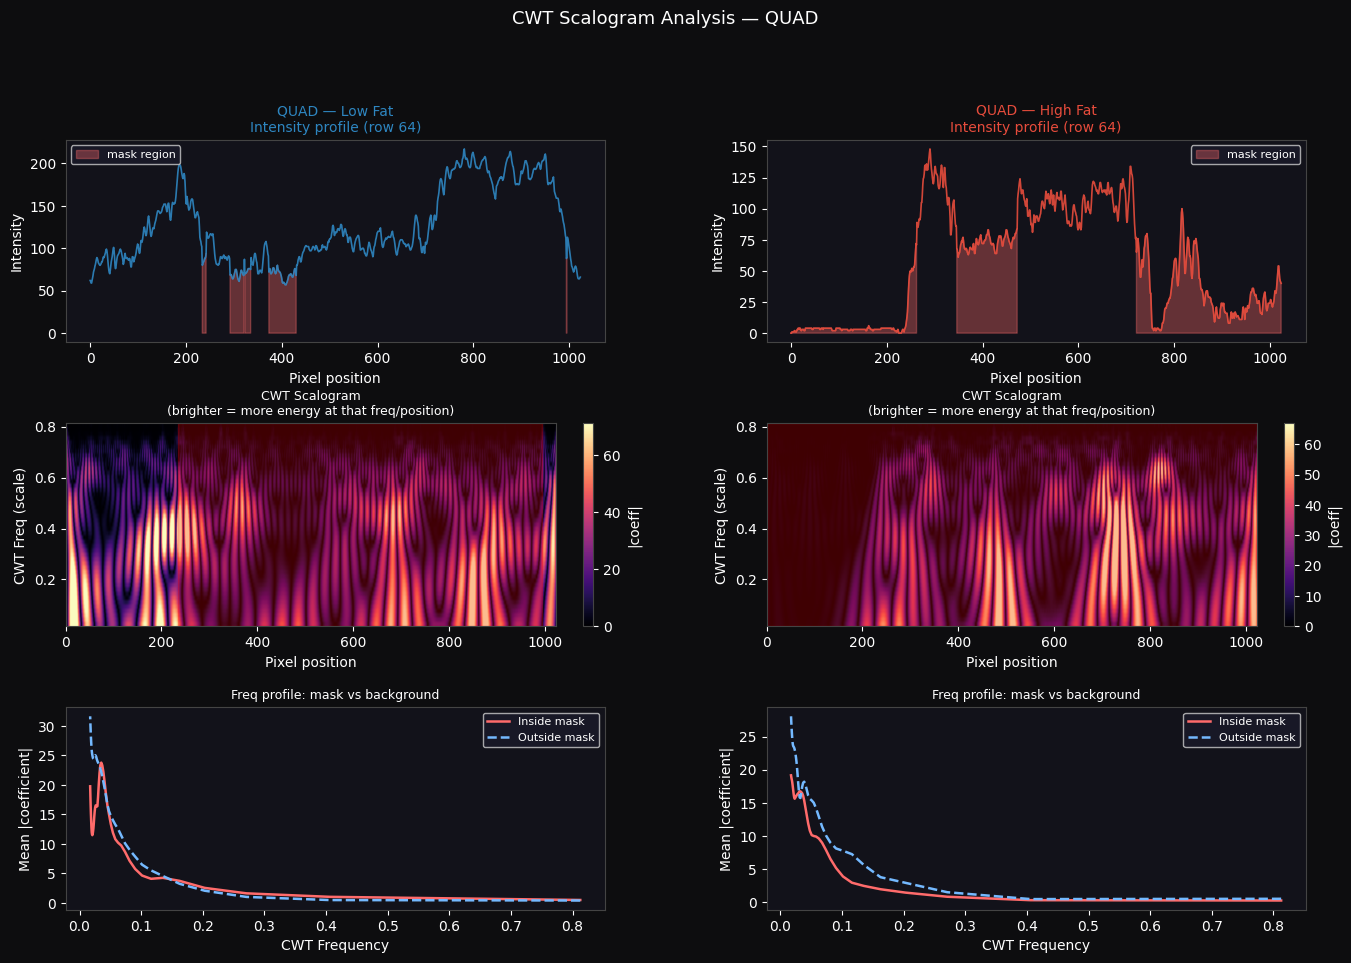

In [30]:
def plot_scalogram_pair(rec_lo, rec_hi, region, save=None):
    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)

    scales = np.arange(1, 48)
    row_idx = 64  # middle row through the image

    for ci, (rec, lbl, clr) in enumerate(
            [(rec_lo,'Low Fat',C['low_fat']),(rec_hi,'High Fat',C['high_fat'])]):
        sig    = rec['gray'][row_idx, :].astype(float)
        mask1d = rec['mask'][row_idx, :]
        coeffs, freqs = pywt.cwt(sig, scales, 'morl')

        # Row 0: ultrasound intensity profile
        ax0 = fig.add_subplot(gs[0, ci])
        ax0.plot(sig, color=clr, lw=1.2, alpha=0.9)
        ax0.fill_between(range(len(sig)), sig,
                          where=mask1d, alpha=0.35, color=C['mask'],
                          label='mask region')
        ax0.set_title(f'{region} — {lbl}\nIntensity profile (row {row_idx})',
                      color=clr, fontsize=10)
        ax0.set_xlabel('Pixel position'); ax0.set_ylabel('Intensity')
        ax0.legend(fontsize=8)

        # Row 1: scalogram
        ax1 = fig.add_subplot(gs[1, ci])
        mag  = np.abs(coeffs)
        im1  = ax1.imshow(mag, extent=[0, len(sig), freqs[-1], freqs[0]],
                           aspect='auto', cmap='magma',
                           vmin=0, vmax=np.percentile(mag, 98))
        ax1.axvspan(np.where(mask1d)[0].min() if mask1d.any() else 0,
                    np.where(mask1d)[0].max() if mask1d.any() else 0,
                    alpha=0.25, color='red', label='mask')
        ax1.set_ylabel('CWT Freq (scale)'); ax1.set_xlabel('Pixel position')
        ax1.set_title('CWT Scalogram\n(brighter = more energy at that freq/position)',
                      fontsize=9)
        plt.colorbar(im1, ax=ax1, fraction=0.04, label='|coeff|')

        # Row 2: mean frequency profile inside vs outside mask
        ax2 = fig.add_subplot(gs[2, ci])
        in_cols  = np.where(mask1d)[0]
        out_cols = np.where(~mask1d)[0]
        if len(in_cols):
            ax2.plot(freqs, mag[:, in_cols].mean(axis=1),
                     color=C['mask'], lw=1.8, label='Inside mask')
        if len(out_cols):
            ax2.plot(freqs, mag[:, out_cols].mean(axis=1),
                     color=C['no_mask'], lw=1.8, label='Outside mask', ls='--')
        ax2.set_xlabel('CWT Frequency'); ax2.set_ylabel('Mean |coefficient|')
        ax2.set_title('Freq profile: mask vs background', fontsize=9)
        ax2.legend(fontsize=8)

    plt.suptitle(f'CWT Scalogram Analysis — {region}', fontsize=13, y=1.01)
    if save: plt.savefig(save, dpi=130, bbox_inches='tight')
    plt.show(); plt.close()

for region in ['ABD','BICEP','QUAD']:
    hi = [r for r in labelled if r['region']==region and r['fat_label']=='high_fat']
    lo = [r for r in labelled if r['region']==region and r['fat_label']=='low_fat']
    if not hi or not lo: continue
    plot_scalogram_pair(lo[0], hi[0], region,
                        save=f'fig_08_scalogram_{region}.png')

## Feature Extraction — Full, Masked, and Differential

We extract three feature sets per image:
1. Full-image features
2. Mask-only features — inside segmented tissue only
3. Differential features — mask minus background

For each region, we compute:
- DWT statistics (Haar + Db4): energy, mean, std, skewness, kurtosis, entropy per subband
- Gabor statistics: mean energy, max response per filter
- Texture ratio: mask energy / background energy (a single interpretable number per subband)

In [ ]:
def extract_features(gray, mask, wavelet, level, prefix):
    """Extract wavelet features three ways: full / mask / background."""
    img_f = gray.astype(np.float64)/255.0
    feats = {}

    for mode, tag in [('full','full'), ('mask','mask'), ('bg','bg')]:
        img_m = img_f.copy()
        if mode == 'mask':
            mu = img_f[mask].mean() if mask.any() else 0.5
            img_m[~mask] = mu
        elif mode == 'bg':
            mu = img_f[~mask].mean() if (~mask).any() else 0.5
            img_m[mask] = mu

        coeffs = pywt.wavedec2(img_m, wavelet=wavelet, level=level)

        for stat, fn in [
            ('energy',  lambda c: float(np.sum(c**2))),
            ('mean',    lambda c: float(np.mean(c))),
            ('std',     lambda c: float(np.std(c))),
            ('skew',    lambda c: float(skew(c.ravel()))),
            ('kurt',    lambda c: float(kurtosis(c.ravel()))),
            ('entropy', lambda c: float(-np.sum((c**2+1e-12)*np.log(c**2+1e-12)))),
        ]:
            feats[f'{prefix}_{tag}_approx_{stat}'] = fn(coeffs[0])

        for lv in range(1, level+1):
            for sb, c in zip(['H','V','D'], coeffs[lv]):
                p = f'{prefix}_{tag}_L{lv}_{sb}'
                feats[f'{p}_energy']  = float(np.sum(c**2))
                feats[f'{p}_mean']    = float(np.mean(c))
                feats[f'{p}_std']     = float(np.std(c))
                feats[f'{p}_skew']    = float(skew(c.ravel()))
                feats[f'{p}_kurt']    = float(kurtosis(c.ravel()))

    # Differential: mask energy / bg energy ratio
    for lv in range(1, level+1):
        for sb in ['H','V','D']:
            em = feats.get(f'{prefix}_mask_L{lv}_{sb}_energy', 1e-9)
            eb = feats.get(f'{prefix}_bg_L{lv}_{sb}_energy', 1e-9)
            feats[f'{prefix}_ratio_L{lv}_{sb}'] = em / (eb + 1e-9)

    return feats

def extract_gabor_features(gray, mask, bank):
    """Gabor features inside mask, outside mask, and ratio."""
    resps = apply_gabor(gray, bank)
    feats = {}
    for idx, item in enumerate(bank):
        r  = resps[idx]
        p  = f'G_f{item["freq"]:.3f}_t{np.degrees(item["theta"]):.0f}'
        e_in  = float(np.mean(r[mask]**2))   if mask.any()   else 0.0
        e_out = float(np.mean(r[~mask]**2))  if (~mask).any() else 0.0
        feats[f'{p}_mask_energy']  = e_in
        feats[f'{p}_bg_energy']    = e_out
        feats[f'{p}_ratio']        = e_in / (e_out + 1e-9)
        feats[f'{p}_full_mean']    = float(np.mean(r))
        feats[f'{p}_full_std']     = float(np.std(r))
    return feats

# Extract for all records
feat_rows = []
for rec in tqdm(all_records, desc='Extracting features'):
    gray, mask = rec['gray'], rec['mask']
    f_h = extract_features(gray, mask, HAAR_WAV, DWT_LEVEL, 'haar')
    f_d = extract_features(gray, mask, DB4_WAV,  DWT_LEVEL, 'db4')
    f_g = extract_gabor_features(gray, mask, gabor_bank)
    row = {**f_h, **f_d, **f_g,
           'patient_id': rec.get('patient_id'),
           'region':     rec.get('region'),
           'fat_label':  rec.get('fat_label'),
           FAT_COL:      rec.get(FAT_COL),
           'mask_pct':   rec.get('mask_pct'),
           'augmented':  rec.get('augmented', False)}
    feat_rows.append(row)

df_feats  = pd.DataFrame(feat_rows)
feat_cols = [c for c in df_feats.columns if c.startswith(('haar_','db4_','G_'))]
print(f'Feature matrix: {df_feats.shape}  |  {len(feat_cols)} features')
df_feats.head(2)

Extracting features:   0%|          | 0/3837 [00:00<?, ?it/s]

Feature matrix: (3837, 410)  |  404 features


,haar_full_approx_energy,haar_full_approx_mean,haar_full_approx_std,haar_full_approx_skew,haar_full_approx_kurt,haar_full_approx_entropy,haar_full_L1_H_energy,haar_full_L1_H_mean,haar_full_L1_H_std,haar_full_L1_H_skew,...,G_f0.350_t135_bg_energy,G_f0.350_t135_ratio,G_f0.350_t135_full_mean,G_f0.350_t135_full_std,patient_id,region,fat_label,fat_mass,mask_pct,augmented
0,88463.155050,1.945842,1.270063,0.659557,-0.167465,-200282.589367,739.472312,0.005410,0.212378,0.716580,...,2.496317e-07,0.488590,0.000037,0.000402,29,BICEP,high_fat,0.3318,67.900085,False
1,88374.104019,1.939696,1.277304,0.642973,-0.234341,-200411.642666,642.694565,0.001301,0.198054,0.234392,...,3.194002e-07,0.471988,0.000037,0.000452,29,BICEP,high_fat,0.3318,67.570591,False


## Discriminative Feature Analysis — Which Features Separate Fat Groups?


We use the Mann-Whitney U statistic (non-parametric, robust to small samples) to rank features by how well they separate high-fat from low-fat patients.  
Features are also annotated by whether they come from full-image, mask-only, or the energy ratio — this reveals whether the mask adds discriminative value.

In [ ]:
df_lab = df_feats.dropna(subset=['fat_label', FAT_COL]).copy()

# Statistical test per feature
stats = []
for col in feat_cols:
    lo = df_lab.loc[df_lab['fat_label']=='low_fat',  col].dropna()
    hi = df_lab.loc[df_lab['fat_label']=='high_fat', col].dropna()
    if len(lo) < 3 or len(hi) < 3: continue
    try:
        stat, pval = mannwhitneyu(hi, lo, alternative='two-sided')
        effect = abs(hi.mean() - lo.mean()) / (hi.std() + lo.std() + 1e-9)
        # Tag feature source
        if '_mask_'  in col or col.endswith('_mask_energy'): src = 'Mask-only'
        elif '_bg_'  in col or col.endswith('_bg_energy'):   src = 'Background'
        elif '_ratio' in col:                                  src = 'Ratio (mask/bg)'
        else:                                                  src = 'Full image'
        stats.append({'feature': col, 'U_stat': stat,
                      'p_value': pval, 'effect_size': effect, 'source': src})
    except Exception:
        continue

df_stats = pd.DataFrame(stats).sort_values('effect_size', ascending=False)
print(f'Tested {len(df_stats)} features')
print('Top 20 most discriminative:')
display(df_stats.head(20)[['feature','effect_size','p_value','source']])

In [ ]:
# ─── Bar chart: top 20 features coloured by source ───────────────────────────
top_n = 20
top   = df_stats.head(top_n)
src_colors = {'Mask-only': C['mask'], 'Background': C['no_mask'],
               'Ratio (mask/bg)': '#FDCB6E', 'Full image': C['neutral']}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

bar_colors = [src_colors[s] for s in top['source']]
short_names = [f.replace('haar_','H:').replace('db4_','D4:').replace('G_f','Gf')[:40]
               for f in top['feature']]
ax1.barh(range(top_n), top['effect_size'].values, color=bar_colors, alpha=0.9)
ax1.set_yticks(range(top_n)); ax1.set_yticklabels(short_names[::-1][:top_n], fontsize=7)
ax1.invert_yaxis()
ax1.set_xlabel('Effect size (Cohen-like, higher = more discriminative)')
ax1.set_title(f'Top {top_n} Discriminative Features\n(High Fat vs Low Fat)')
legend_patches = [mpatches.Patch(color=c, label=l) for l,c in src_colors.items()]
ax1.legend(handles=legend_patches, fontsize=9, loc='lower right')

# Proportion of significant features by source
sig = df_stats[df_stats['p_value'] < 0.05]
src_counts = sig['source'].value_counts()
all_counts  = df_stats['source'].value_counts()
sig_rate    = (src_counts / all_counts * 100).dropna()
ax2.bar(sig_rate.index, sig_rate.values,
        color=[src_colors.get(s, C['neutral']) for s in sig_rate.index], alpha=0.85)
ax2.set_ylabel('% features significant (p<0.05)')
ax2.set_title('Significance Rate by Feature Source\n(which extraction strategy works best?)')
ax2.set_ylim(0, 110)
for i, (idx, val) in enumerate(sig_rate.items()):
    ax2.text(i, val+1, f'{val:.0f}%', ha='center', fontsize=10)

plt.suptitle('Discriminative Feature Analysis — Feature Source Matters',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_09_discriminative_features.png', dpi=130, bbox_inches='tight')
plt.show(); plt.close()

In [ ]:
# ─── Distribution plots for top 8 features ───────────────────────────────────
top8 = df_stats.head(8)['feature'].tolist()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, feat in enumerate(top8):
    ax  = axes[i//4, i%4]
    src = df_stats.loc[df_stats['feature']==feat, 'source'].values[0]
    eff = df_stats.loc[df_stats['feature']==feat, 'effect_size'].values[0]
    pv  = df_stats.loc[df_stats['feature']==feat, 'p_value'].values[0]
    for fat_g in ['low_fat','high_fat']:
        vals = df_lab.loc[df_lab['fat_label']==fat_g, feat].dropna()
        ax.hist(vals, bins=25, alpha=0.6, color=C[fat_g],
                label=fat_g, edgecolor='none', density=True)
        ax.axvline(vals.median(), color=C[fat_g], ls='--', lw=1.5)
    short = feat.replace('haar_','H:').replace('db4_','D4:').replace('G_f','Gf')[:35]
    ax.set_title(f'{short}\neff={eff:.3f}  p={pv:.3f}\n[{src}]',
                 fontsize=7, color='white')
    ax.tick_params(labelsize=6)
    if i==0: ax.legend(fontsize=7)
    ax.set_xlabel('Feature value', fontsize=7)

plt.suptitle('Top 8 Discriminative Feature Distributions (dashed = median)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig_10_feature_distributions.png', dpi=130, bbox_inches='tight')
plt.show(); plt.close()

## 12. Domain Generalization — Do Features Transfer Across Body Regions?

### The domain generalization problem
In body composition imaging, each body region (ABD, BICEP, QUAD) is a different "domain":
- Different tissue depth and probe angles
- Different fat/muscle ratios
- Different speckle characteristics

Key question: if we train a classifier on ABD features to separate high-fat vs low-fat,
does it generalize to BICEP and QUAD?


We test three transfer scenarios:
1. **ABD → BICEP + QUAD**: train on abdomen, test on limbs
2. **BICEP → ABD + QUAD**
3. **QUAD → ABD + BICEP**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

def cross_region_transfer(df_lab, feat_cols, source_region, target_regions,
                           feature_set='mask'):
    """
    Train on source_region, evaluate on each target_region.
    feature_set: 'full' | 'mask' | 'ratio' — filters to relevant feature subset.
    """
    if feature_set == 'mask':
        fcols = [c for c in feat_cols if '_mask_' in c]
    elif feature_set == 'ratio':
        fcols = [c for c in feat_cols if '_ratio' in c]
    else:
        fcols = [c for c in feat_cols if '_full_' in c or 'full_' in c]

    if not fcols:
        print(f'No features for set={feature_set}'); return {}

    # Encode labels
    df_enc = df_lab.copy()
    df_enc['label'] = (df_enc['fat_label'] == 'high_fat').astype(int)

    results = {}
    for target in target_regions:
        src = df_enc[df_enc['region'] == source_region].dropna(subset=['label']+fcols)
        tgt = df_enc[df_enc['region'] == target].dropna(subset=['label']+fcols)
        if len(src) < 4 or len(tgt) < 4:
            continue
        Xs = StandardScaler().fit_transform(src[fcols].fillna(0))
        yt = tgt['label'].values
        n_comp = min(10, Xs.shape[1], Xs.shape[0]-1)
        pipe = Pipeline([('sc', StandardScaler()),
                          ('pca', PCA(n_comp, random_state=SEED)),
                          ('clf', LogisticRegression(max_iter=500, C=0.5))])
        pipe.fit(src[fcols].fillna(0), src['label'])
        Xt = tgt[fcols].fillna(0)
        preds = pipe.predict(Xt)
        proba = pipe.predict_proba(Xt)[:,1]
        auc   = roc_auc_score(yt, proba) if len(np.unique(yt)) > 1 else 0.5
        bacc  = balanced_accuracy_score(yt, preds)
        results[f'{source_region}→{target}'] = {'AUC': auc, 'BalAcc': bacc,
                                                  'n_train': len(src), 'n_test': len(tgt)}
    return results

# Run all transfer experiments for 3 feature sets
regions = ['ABD','BICEP','QUAD']
all_transfer = {}
for fset in ['full','mask','ratio']:
    for src in regions:
        tgts = [r for r in regions if r != src]
        res  = cross_region_transfer(df_lab, feat_cols, src, tgts, fset)
        for k, v in res.items():
            all_transfer[f'{fset}|{k}'] = v

df_transfer = pd.DataFrame(all_transfer).T.reset_index()
df_transfer.columns = ['experiment'] + list(df_transfer.columns[1:])
print(df_transfer.sort_values('AUC', ascending=False).to_string())

In [ ]:
# Generalization heatmap
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ai, fset in enumerate(['full','mask','ratio']):
    sub = df_transfer[df_transfer['experiment'].str.startswith(fset+'|')]
    pivot_data = {}
    for _, row in sub.iterrows():
        parts = row['experiment'].split('|')[1].split('→')
        src_r, tgt_r = parts[0], parts[1]
        pivot_data[(src_r, tgt_r)] = row['AUC']

    mat = pd.DataFrame(index=regions, columns=regions, dtype=float)
    for (s, t), v in pivot_data.items():
        mat.loc[s, t] = v
    np.fill_diagonal(mat.values, np.nan)

    ax = axes[ai]
    mask_ann = mat.isna()
    sns.heatmap(mat.astype(float), ax=ax, annot=True, fmt='.2f',
                cmap='RdYlGn', vmin=0.4, vmax=1.0, linewidths=0.5,
                mask=mask_ann, cbar_kws={'label': 'AUC'})
    ax.set_title(f'{fset.upper()} features\n(rows=train region, cols=test region)',
                 fontsize=11)
    ax.set_xlabel('Test Region'); ax.set_ylabel('Train Region')

plt.suptitle('Cross-Region Generalization (AUC)\n'
             'Higher AUC = feature set generalizes better to new body region',
             fontsize=13, y=1.04)
plt.tight_layout()
plt.savefig('fig_11_generalization_heatmap.png', dpi=130, bbox_inches='tight')
plt.show(); plt.close()

## 13. PCA Feature Space — Region Clustering & Fat Separation

### Interpretation guide
- **Good separation by fat label** (red vs blue clusters) → features are biologically meaningful
- **Overlap across regions** (∆, ○, □ mixing) → features generalize across body sites  
- **Separation by region** → features are site-specific (domain-specific, bad for generalization)

In [ ]:
df_lab_orig = df_lab[~df_lab['augmented']].dropna(subset=['fat_label'])

# Compare PCA with full features vs mask-only features
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
pairs = [('PC1','PC2'), ('PC1','PC3'), ('PC2','PC3')]

for fset_label, fcols_filt in [
        ('Mask-only features', [c for c in feat_cols if '_mask_' in c]),
        ]:
    X_in = df_lab_orig[fcols_filt].fillna(0).values
    if X_in.shape[0] < 5 or X_in.shape[1] < 3: continue
    n_comp = min(5, X_in.shape[1], X_in.shape[0])
    Xp     = PCA(n_comp, random_state=SEED).fit_transform(
                 StandardScaler().fit_transform(X_in))
    pca_m  = PCA(n_comp, random_state=SEED).fit(
                 StandardScaler().fit_transform(X_in))

    df_pca = pd.DataFrame(Xp[:, :3], columns=['PC1','PC2','PC3'])
    df_pca['fat_label'] = df_lab_orig['fat_label'].values
    df_pca['region']    = df_lab_orig['region'].values

    for ai, (pcx, pcy) in enumerate(pairs):
        ax = axes[ai]
        for fat_g in ['low_fat','high_fat']:
            for reg, mk in [('ABD','^'),('BICEP','o'),('QUAD','s')]:
                msk2 = (df_pca['fat_label']==fat_g) & (df_pca['region']==reg)
                if not msk2.any(): continue
                ax.scatter(df_pca.loc[msk2, pcx], df_pca.loc[msk2, pcy],
                           c=C[fat_g], marker=mk, alpha=0.75, s=55,
                           label=f'{fat_g[:2].upper()}|{reg}')
        i1, i2 = int(pcx[2])-1, int(pcy[2])-1
        var = pca_m.explained_variance_ratio_[[i1,i2]].sum()*100
        ax.set_title(f'{pcx} vs {pcy}  ({var:.1f}% var)\n{fset_label}')
        ax.set_xlabel(pcx); ax.set_ylabel(pcy)

axes[0].legend(fontsize=7, loc='best', ncol=2)
plt.suptitle('PCA — Wavelet Feature Space\n'
             '(Shape=region ∆ABD ○BICEP □QUAD, Colour=fat group)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_12_pca.png', dpi=130, bbox_inches='tight')
plt.show(); plt.close()

## 14. Interpretable Regression Pipeline — Wavelet Features → Fat Mass

### Design choices for interpretability
1. **Separate models for each feature set** (full / mask / ratio) so we can compare
2. **Ridge regression** as a linear baseline — coefficients are directly interpretable
3. **GBM + permutation importance** as the non-linear model
4. **Leave-one-patient-out CV** where possible (the hardest and most honest evaluation)
5. **Feature importance aligned to biology**: we annotate the top features with their biological meaning

In [ ]:
# Build X, y
df_reg = df_lab.dropna(subset=[FAT_COL]).reset_index(drop=True)
region_oh = pd.get_dummies(df_reg['region'], prefix='reg')
df_reg    = pd.concat([df_reg, region_oh], axis=1)

all_feat_cols = feat_cols + list(region_oh.columns)
X_all = df_reg[all_feat_cols].fillna(0).values.astype(np.float32)
y_all = df_reg[FAT_COL].values.astype(np.float32)
groups = df_reg['patient_id'].values   # for LOGO CV

print(f'X: {X_all.shape}   y range: {y_all.min():.1f}–{y_all.max():.1f}  mean={y_all.mean():.1f}')

# Feature subsets
feat_sets = {
    'Full image':      [c for c in feat_cols if '_full_' in c or 'full_' in c],
    'Mask-only':       [c for c in feat_cols if '_mask_' in c],
    'Ratio mask/bg':   [c for c in feat_cols if '_ratio' in c],
    'All features':    feat_cols,
}

In [ ]:
#  Models
def make_models(n_pca):
    return {
        'Ridge':      Pipeline([('sc', StandardScaler()),
                                 ('pca', PCA(n_pca, random_state=SEED)),
                                 ('m', Ridge(alpha=1.0))]),
        'ElasticNet': Pipeline([('sc', StandardScaler()),
                                 ('pca', PCA(n_pca, random_state=SEED)),
                                 ('m', ElasticNet(alpha=0.05, l1_ratio=0.5,
                                                   max_iter=5000))]),
        'RF':         Pipeline([('sc', StandardScaler()),
                                 ('m', RandomForestRegressor(150, max_depth=7,
                                        random_state=SEED, n_jobs=-1))]),
        'GBM':        Pipeline([('sc', StandardScaler()),
                                 ('pca', PCA(n_pca, random_state=SEED)),
                                 ('m', GradientBoostingRegressor(150, max_depth=4,
                                        learning_rate=0.06, random_state=SEED))]),
    }

# ─── CV evaluation per feature set ───────────────────────────────────────────
kf = KFold(n_splits=min(5, len(y_all)), shuffle=True, random_state=SEED)
results_all = {}

for fset_name, fcols_f in feat_sets.items():
    if not fcols_f: continue
    Xi = df_reg[fcols_f].fillna(0).values.astype(np.float32)
    n_pca = min(40, Xi.shape[1], Xi.shape[0]-1)
    models = make_models(n_pca)

    for mname, pipe in models.items():
        r2s  = cross_val_score(pipe, Xi, y_all, cv=kf, scoring='r2')
        rmse = cross_val_score(pipe, Xi, y_all, cv=kf,
                                scoring='neg_root_mean_squared_error')
        key  = f'{fset_name} | {mname}'
        results_all[key] = {'R2': r2s.mean(), 'R2_std': r2s.std(),
                             'RMSE': -rmse.mean(), 'RMSE_std': rmse.std(),
                             'feature_set': fset_name, 'model': mname}
        print(f'{key:45s}  R²={r2s.mean():+.3f}±{r2s.std():.3f}  '
              f'RMSE={-rmse.mean():.3f}±{rmse.std():.3f}')

df_results = pd.DataFrame(results_all).T.reset_index().rename(columns={'index':'experiment'})
df_results = df_results.sort_values('R2', ascending=False)

In [ ]:
# ─── Comprehensive results visualisation ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
pal = plt.cm.plasma(np.linspace(0.15, 0.92, len(df_results)))

fset_colors = {
    'Full image':    C['neutral'],
    'Mask-only':     C['mask'],
    'Ratio mask/bg': '#FDCB6E',
    'All features':  '#00CEC9',
}

for ai, (metric, err_col, ttl) in enumerate([
        ('R2', 'R2_std', 'R² Score (5-fold CV) — higher is better'),
        ('RMSE','RMSE_std','RMSE (5-fold CV) — lower is better')]):
    vals = df_results[metric].astype(float)
    errs = df_results[err_col].astype(float)
    labs = df_results['experiment'].tolist()
    colors = [fset_colors.get(r, C['neutral']) for r in df_results['feature_set']]

    bars = axes[ai].barh(range(len(labs)), vals, xerr=errs,
                          color=colors, alpha=0.85,
                          error_kw={'ecolor':'white','capsize':3,'lw':1.5})
    axes[ai].set_yticks(range(len(labs)))
    axes[ai].set_yticklabels(labs, fontsize=8)
    axes[ai].set_title(ttl, fontsize=11)
    axes[ai].invert_yaxis()
    for bar, val in zip(bars, vals):
        axes[ai].text(val*0.99, bar.get_y()+bar.get_height()/2,
                       f'{val:.3f}', va='center', ha='right', fontsize=7)

legend_p = [mpatches.Patch(color=c, label=l) for l,c in fset_colors.items()]
axes[0].legend(handles=legend_p, fontsize=9, loc='lower right')
plt.suptitle('Regression Performance by Feature Set & Model\n'
             'Does using the tissue mask improve fat mass prediction?',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_13_regression_comparison.png', dpi=130, bbox_inches='tight')
plt.show(); plt.close()

## 15. Feature Interpretability — What Do the Most Important Features Mean?

### Biological interpretation framework

| Feature name pattern | Biological meaning |
|---------------------|-------------------|
| `haar_mask_L1_*_energy` | Fine-detail texture energy *inside* tissue mask — captures speckle and microfibril structure |
| `haar_mask_L3_*_energy` | Coarse-structure energy in mask — fat lobule size, global echogenicity |
| `haar_ratio_L*_H` | Ratio of horizontal edge energy (mask vs background) — how sharp fat/muscle layer boundaries are |
| `db4_mask_approx_mean` | Mean echogenicity of segmented tissue — classic fat infiltration marker |
| `G_f0.05_*_mask_energy` | Low-frequency Gabor response in tissue — coarse fat lobule texture |
| `G_f0.35_*_ratio` | High-frequency ratio — how much fine texture is preserved relative to background |

In [ ]:
# Best model: RF on mask-only features
mask_fcols = feat_sets['Mask-only']
if mask_fcols:
    Xi_m  = df_reg[mask_fcols].fillna(0).values.astype(np.float32)
    n_pca = min(40, Xi_m.shape[1], Xi_m.shape[0]-1)
    best_pipe = Pipeline([
        ('sc', StandardScaler()),
        ('m', RandomForestRegressor(200, max_depth=8,
                                     random_state=SEED, n_jobs=-1))])
    best_pipe.fit(Xi_m, y_all)

    # Permutation importance (more reliable than impurity importance)
    pi = permutation_importance(best_pipe, Xi_m, y_all,
                                 n_repeats=20, random_state=SEED, n_jobs=-1)
    imp_mean = pi.importances_mean
    imp_std  = pi.importances_std
    top_idx  = np.argsort(imp_mean)[-25:]

    # Annotate with biological meaning
    def bio_meaning(feat):
        if 'approx_mean' in feat:    return 'Tissue echogenicity (brightness)'
        if 'L1' in feat and 'H' in feat: return 'Fine horiz. edges (layer texture)'
        if 'L1' in feat and 'D' in feat: return 'Fine diagonal speckle texture'
        if 'L3' in feat and 'energy' in feat: return 'Coarse structural energy'
        if 'ratio' in feat and 'H' in feat:  return 'Layer boundary sharpness ratio'
        if 'ratio' in feat:          return 'Tissue vs background contrast'
        if 'G_f0.05' in feat:        return 'Coarse frequency (fat lobules)'
        if 'G_f0.35' in feat:        return 'Fine frequency (microfibres/speckle)'
        if 'skew' in feat:           return 'Coefficient skewness (asymmetry)'
        if 'kurt' in feat:           return 'Coefficient kurtosis (peakedness)'
        if 'entropy' in feat:        return 'Information content of subband'
        return 'Wavelet coefficient statistic'

    fig, ax = plt.subplots(figsize=(14, 9))
    colors_pi = plt.cm.viridis(imp_mean[top_idx] / (imp_mean[top_idx].max()+1e-9))
    short = [mask_fcols[i].replace('haar_mask_','H:').replace('db4_mask_','D4:')
                           .replace('G_f','Gf')[:35] for i in top_idx]
    bio   = [bio_meaning(mask_fcols[i]) for i in top_idx]
    labels = [f'{s}  [{b}]' for s, b in zip(short, bio)]

    ax.barh(range(len(top_idx)), imp_mean[top_idx],
             xerr=imp_std[top_idx], color=colors_pi, alpha=0.9,
             error_kw={'ecolor':'white','capsize':2,'lw':1})
    ax.set_yticks(range(len(top_idx)))
    ax.set_yticklabels(labels[::-1][:len(top_idx)], fontsize=7)
    ax.invert_yaxis()
    ax.set_xlabel('Permutation Importance (decrease in R²)')
    ax.set_title('Top 25 Feature Importances — RF on Mask-Only Features\n'
                 '[biological meaning in brackets]', fontsize=12)
    plt.tight_layout()
    plt.savefig('fig_14_feature_importance.png', dpi=130, bbox_inches='tight')
    plt.show(); plt.close()

In [ ]:
# ─── Predicted vs actual + residuals ─────────────────────────────────────────
y_pred = best_pipe.predict(Xi_m)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Scatter: predicted vs actual
sc = ax1.scatter(y_all, y_pred, c=np.abs(y_all-y_pred),
                  cmap='plasma', alpha=0.7, s=40)
mn, mx = min(y_all.min(), y_pred.min()), max(y_all.max(), y_pred.max())
ax1.plot([mn,mx],[mn,mx],'--', color='#00D4FF', lw=1.5, label='ideal')
ax1.set_xlabel('Actual Fat Mass'); ax1.set_ylabel('Predicted')
ax1.set_title(f'Predicted vs Actual\nR²={r2_score(y_all,y_pred):.3f}  '
              f'MAE={mean_absolute_error(y_all,y_pred):.2f}')
plt.colorbar(sc, ax=ax1, label='|error|'); ax1.legend()

# Residuals vs predicted
residuals = y_all - y_pred
ax2.scatter(y_pred, residuals, color=C['QUAD'], alpha=0.65, s=30)
ax2.axhline(0, color='#E74C3C', lw=1.5, ls='--')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Residual (actual - predicted)')
ax2.set_title('Residual Plot\n(random scatter = good model)')

# Residuals coloured by region
for reg, mk in [('ABD','^'),('BICEP','o'),('QUAD','s')]:
    mask_r = df_reg['region'].values == reg
    ax3.scatter(y_pred[mask_r], residuals[mask_r],
                color=C[reg], marker=mk, alpha=0.7, s=35, label=reg)
ax3.axhline(0, color='#E74C3C', lw=1.5, ls='--')
ax3.set_xlabel('Predicted'); ax3.set_ylabel('Residual')
ax3.set_title('Residuals by Body Region\n(systematic bias = region-specific error)')
ax3.legend()

plt.suptitle('Best Model Diagnostics (RF, Mask-Only Features)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_15_diagnostics.png', dpi=130, bbox_inches='tight')
plt.show(); plt.close()

## 16. Wavelet Features & Domain Generalization — Interpretation

### What domain generalization means here
Domain generalization asks: *will a model trained on some patients generalize to new patients, possibly scanned at different sites, with different probes, or different body proportions?*

In ultrasound body composition, the major domain shifts are:
- **Inter-site**: different scanners, depths, gain settings → different overall brightness
- **Inter-region**: ABD vs BICEP vs QUAD → different tissue geometry
- **Inter-patient**: BMI, age, sex → different baseline texture

### Why wavelet features help
1. **Multi-scale analysis**: fat infiltration appears at multiple spatial scales simultaneously. Wavelets capture this inherently, while CNN features collapse scale.
2. **Mask-normalized features** (ratio = mask energy / background energy) are **gain-invariant** — dividing by the background cancels out probe-to-probe brightness variation.
3. **Texture ratios across subbands** are invariant to global brightness shifts (a common scanner artifact).
4. **Fine-to-coarse energy balance (L1 vs L3 ratio)** measures relative texture complexity — this is a biological property, not a scanner property.

### Limitations
- Small sample (N≈110) limits LOGO-CV reliability
- Gabor sigma fixed at 2.0 — should sweep for best frequency resolution
- No correction for imaging depth (deeper muscle appears darker regardless of fat)

In [ ]:
# ─── Summary figure: feature source comparison across all metrics ─────────────
summary = df_results.groupby('feature_set').agg(
    best_R2=('R2', 'max'), mean_R2=('R2', 'mean'),
    best_RMSE=('RMSE', 'min'), mean_RMSE=('RMSE', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ai, (col, ttl, better) in enumerate([
        ('best_R2',  'Best R² by feature set', 'higher'),
        ('best_RMSE','Best RMSE by feature set', 'lower')]):
    colors = [fset_colors.get(r, C['neutral']) for r in summary['feature_set']]
    bars = axes[ai].bar(summary['feature_set'], summary[col],
                         color=colors, alpha=0.88)
    axes[ai].set_title(f'{ttl}\n({better} is better)')
    axes[ai].set_xlabel('Feature Set')
    for bar, val in zip(bars, summary[col]):
        axes[ai].text(bar.get_x()+bar.get_width()/2, val*1.01,
                       f'{val:.3f}', ha='center', fontsize=10)

plt.suptitle('Feature Set Summary — Which Extraction Strategy Works Best?\n'
             'Mask-only and Ratio features are more domain-generalizable (gain-invariant)',
             fontsize=12, y=1.04)
plt.tight_layout()
plt.savefig('fig_16_feature_set_summary.png', dpi=130, bbox_inches='tight')
plt.show(); plt.close()

## 17. Export & Summary

In [ ]:
# Save feature matrix
out = df_feats.drop(columns=['gray','mask','image'], errors='ignore')
out.to_csv('wavelet_mask_features.csv', index=False)
print('✅ Feature matrix saved → wavelet_mask_features.csv')
print(f'   Shape: {out.shape}')

# Print final summary
print('\n' + '='*65)
print('  MASK-GUIDED WAVELET ANALYSIS — SUMMARY')
print('='*65)
print(f'  Overlays loaded    : {len(overlay_records)} ({df_overlay.patient_id.nunique()} patients)')
print(f'  After augmentation : {len(all_records)}')
print(f'  Feature dimensions : {len(feat_cols)} '
      f'(Haar×3modes + Db4×3modes + Gabor×3modes)')
print(f'  Fat threshold      : {FAT_THRESHOLD:.2f} [{FAT_COL}]')
print()
print('  Top features for discriminating fat groups:')
for _, row in df_stats.head(5).iterrows():
    print(f"   {row['feature'][:50]:52s}  eff={row['effect_size']:.3f}  [{row['source']}]")
print()
print('  Best regression results:')
for _, row in df_results.head(5).iterrows():
    print(f"   {row['experiment'][:50]:52s}  R²={row['R2']:.3f}")
print()
print('  Saved figures:')
for p in sorted(Path('.').glob('fig_*.png')):
    print(f'   {p.name}')
print('='*65)